# 微分方程与线性代数 — 读书笔记
**教材：** Goode & Annin, *Differential Equations and Linear Algebra*, 4th Edition


In [11]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.figsize': (8, 5), 'font.size': 11})

---
## 第 1 章 — 一阶微分方程

### 1.1 核心概念

**一阶 ODE** 的一般形式：
$$\frac{dy}{dx} = f(x, y)$$

**存在唯一性定理（Theorem 1.3.2）：** 若 $f(x,y)$ 及 $\partial f/\partial y$ 在包含 $(x_0, y_0)$ 的矩形 $R$ 上连续，则初值问题 $y'=f(x,y),\; y(x_0)=y_0$ 在 $x_0$ 的某邻域 $I$ 上有唯一解。

### 1.2 可分离方程
若 $\frac{dy}{dx} = g(x)h(y)$，分离变量后积分：
$$\int \frac{1}{h(y)}\,dy = \int g(x)\,dx + C$$

### 1.3 一阶线性方程

**"线性"的含义：** 方程对未知函数 $y$ 及其导数 $y'$ 是**一次的**——没有 $y^2$、$yy'$、$\sin(y)$ 之类的项。具体来说：

| 线性 ✓ | 非线性 ✗ | 原因 |
|---------|----------|------|
| $y' + 2xy = e^x$ | $y' + y^2 = 0$ | $y^2$：$y$ 出现了二次 |
| $y' - y = \sin x$ | $yy' = x$ | $yy'$：$y$ 和 $y'$ 相乘 |
| $y' + (\cos x)\,y = x^3$ | $y' = e^y$ | $e^y$：$y$ 在非线性函数里 |

> 注意：$p(x)$ 和 $q(x)$ 可以是 $x$ 的任意函数（甚至很复杂），**只要 $y$ 和 $y'$ 都只以一次幂出现**，就是线性的。

标准形式：$\frac{dy}{dx} + p(x)y = q(x)$

**积分因子（Integrating Factor）：** $I(x) = e^{\int p(x)\,dx}$

**通解：**
$$y(x) = e^{-\int p\,dx}\left[\int q(x)\,e^{\int p\,dx}\,dx + C\right]$$

### 1.4 经典应用

**① Malthus 人口模型** — 假设细菌增长速率正比于当前数量：

$$\frac{dP}{dt} = kP \quad \Rightarrow \quad P(t) = P_0 e^{kt}$$

这是最简单的指数增长，$k>0$ 时种群无限增长。现实中不可能持续，所以有了 ↓

**② Logistic 模型** — 加入环境容纳量 $C$（资源有限，种群不能无限增长）：

$$\frac{dP}{dt} = k\left(1 - \frac{P}{C}\right)P$$

- $P \ll C$ 时退化为指数增长；$P \to C$ 时增长趋于零。
- 解是 S 形曲线（sigmoid），最终稳定在 $P = C$。

**③ Newton 冷却定律** — 物体温度 $T$ 向环境温度 $T_m$ 指数趋近：

$$\frac{dT}{dt} = -k(T - T_m) \quad \Rightarrow \quad T(t) = T_m + (T_0 - T_m)e^{-kt}$$

场景：一杯热咖啡放在室温环境中，温差越大散热越快，最终趋于室温。

**④ 混合问题（Mixing Problem）** — 水箱中溶液的浓度变化：

$$\frac{dA}{dt} = \underbrace{c_1 r_1}_{\text{流入速率}} - \underbrace{\frac{A}{V}\,r_2}_{\text{流出速率}}$$

场景：水箱初始有 $V_0$ 升溶液，浓度为 $c_1$ 的新液以 $r_1$ 升/分钟流入，搅拌均匀后以 $r_2$ 升/分钟流出。$A(t)$ 是箱内溶质总量，$V(t) = V_0 + (r_1 - r_2)t$ 是箱内液体体积。这是一阶线性 ODE，用积分因子求解。

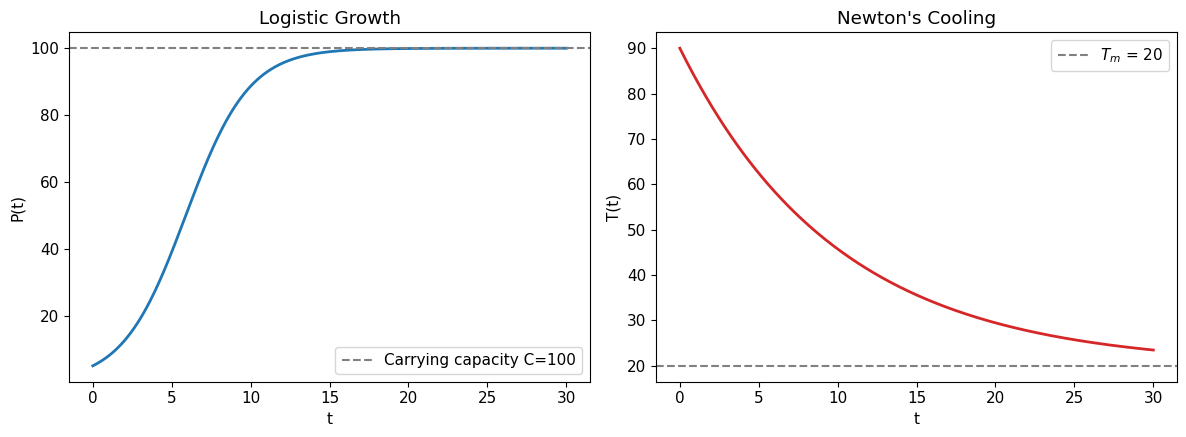

In [39]:
# Example 1: Logistic population model  dP/dt = k(1 - P/C)P
k, C_cap, P0 = 0.5, 100, 5
t = np.linspace(0, 30, 300)
P_exact = C_cap / (1 + ((C_cap - P0) / P0) * np.exp(-k * t))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(t, P_exact, lw=2)
axes[0].axhline(C_cap, ls='--', color='gray', label=f'Carrying capacity C={C_cap}')
axes[0].set(xlabel='t', ylabel='P(t)', title='Logistic Growth')
axes[0].legend()

# Example 2: Newton's law of cooling
T_m, T0, k_cool = 20, 90, 0.1
T_exact = T_m + (T0 - T_m) * np.exp(-k_cool * t)
axes[1].plot(t, T_exact, lw=2, color='tab:red')
axes[1].axhline(T_m, ls='--', color='gray', label=f'$T_m$ = {T_m}')
axes[1].set(xlabel='t', ylabel='T(t)', title="Newton's Cooling")
axes[1].legend()
plt.tight_layout()
plt.show()

#### Slope Field

对一阶 ODE $y' = f(x,y)$，**不用求解**就能看出解曲线的整体走向：

**做法：** 在 $(x,y)$ 平面上取很多网格点，在每个点画一条小线段，斜率 = $f(x,y)$。

**原理：** 解曲线 $y(x)$ 在每一点的切线斜率就是 $y' = f(x,y)$，所以解曲线一定**处处与小线段相切**。把所有线段画满平面，解曲线就像"顺着水流的轨迹"自然显现。

**注意：** 一阶 ODE 的解通常不是一条曲线，而是一簇解曲线；给定不同初始条件 $y(x_0)=y_0$，就会从这簇曲线中选出不同的一条。

**下面的例子** $y' = y - x$：
- 在 $(0, 0)$ 处，斜率 $= 0 - 0 = 0$（水平）
- 在 $(0, 2)$ 处，斜率 $= 2 - 0 = 2$（陡峭向上）
- 在 $(2, 0)$ 处，斜率 $= 0 - 2 = -2$（陡峭向下）

其中 $y = x + 1$ 这条线很特殊：所有经过它的线段斜率恰好 = 1, 这条线本身的斜率，所以它本身就是一条解曲线，其他解曲线都不会穿过它（存在唯一性定理）。

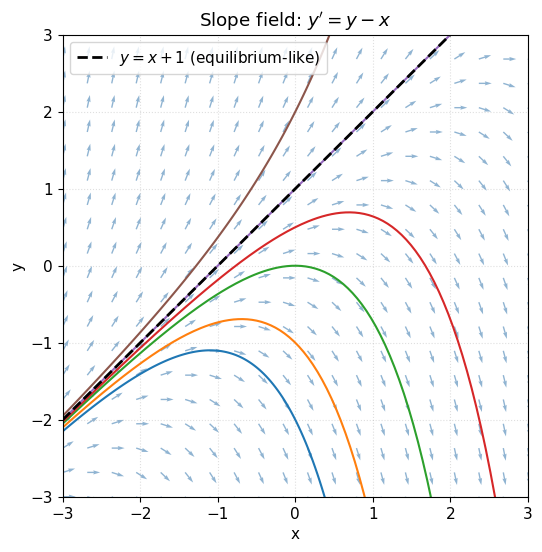

In [4]:
# Example 3: Slope field for dy/dx = y - x  (textbook Example 1.3.7)
x_grid = np.linspace(-3, 3, 20)
y_grid = np.linspace(-3, 3, 20)
X, Y = np.meshgrid(x_grid, y_grid)
dY = Y - X
dX = np.ones_like(dY)
norm = np.sqrt(dX**2 + dY**2)
dX /= norm
dY /= norm

plt.figure(figsize=(6, 6))
# plot the slope field
plt.quiver(X, Y, dX, dY, color='steelblue', alpha=0.6)

# Exact solution: y(x) = Ce^x + x + 1 for various C
x_sol = np.linspace(-3, 3, 200)
# give different value of initial y0 plot different solutions
for y0 in [-2, -1, 0, 0.5, 1, 2]:
    C_val = y0 - 0 - 1  # y(0)=y0 => C = y0 - 1
    y_sol = C_val * np.exp(x_sol) + x_sol + 1
    # plot the solution in the range of -4 to 4
    mask = np.abs(y_sol) < 4
    plt.plot(x_sol[mask], y_sol[mask], lw=1.5)

plt.plot(x_sol, x_sol + 1, 'k--', lw=2, label='$y = x + 1$ (equilibrium-like)')
plt.xlim(-3, 3); plt.ylim(-3, 3)
plt.xlabel('x'); plt.ylabel('y')
plt.title("Slope field: $y' = y - x$")
plt.legend()
plt.grid(True, ls=':', alpha=0.4)
plt.show()

#### 数值方法:
当 ODE 解不出解析解时怎么办?

前面的一阶线性方程 $y' + p(x)y = q(x)$ 可以用积分因子**写出精确公式**。但现实中大多数 ODE（尤其是非线性的）**没有解析解**，只能靠数值方法一步一步"走"出近似解。

**核心思路都一样：** 已知 $y(x_0) = y_0$，要算 $y(x_0 + h)$。因为 $y' = f(x,y)$ 给出当前的"斜率"，所以可以顺着斜率往前走一小步 $h$。

**使用前提：** 下面这些公式默认 ODE 已经写成**显式一阶形式**
$$y'=f(x,y)$$
这里的 $f(x,y)$ 是“斜率函数”，表示 $\frac{dy}{dx}$ 的表达式；它不是 $f'$。如果方程还不是这种形式，需要先整理成 $y'=$ 某个关于 $x,y$ 的表达式，或者把高阶 ODE 改写成一阶系统。

**三种方法对比：**

| 方法 | 思路 | 精度 |
|------|------|------|
| **Euler** | 用当前点的斜率直走一步：$y_{n+1} = y_n + h\,f(x_n, y_n)$ | $O(h)$，最粗糙 |
| **Modified Euler (Heun)** | 先 Euler 走一步得到"预测值"，再用起点和终点的斜率**取平均**修正 | $O(h^2)$，好一个数量级 |
| **RK4** | 在一步之内算 4 个不同位置的斜率（$k_1, k_2, k_3, k_4$），加权平均 | $O(h^4)$，精度极高 |

**统一 setup：** 给定初值问题
$$y' = f(x,y), \qquad y(x_0)=y_0$$
选步长 $h$，令 $x_n=x_0+nh$，从已知的 $(x_n,y_n)$ 递推近似下一个点 $(x_{n+1},y_{n+1})$。

**1. Euler method**

公式：
$$y_{n+1}=y_n+h f(x_n,y_n)$$

算法：
1. 在当前点算斜率 $s=f(x_n,y_n)$；
2. 沿着这个斜率走一步：$y_{n+1}=y_n+hs$；
3. 更新 $x_{n+1}=x_n+h$。

它没有额外 setup，只用当前点的斜率，所以简单但误差最大。

**2. Modified Euler / Heun method**

先预测，再修正：
$$\tilde y_{n+1}=y_n+h f(x_n,y_n)$$
$$y_{n+1}=y_n+\frac{h}{2}\left[f(x_n,y_n)+f(x_{n+1},\tilde y_{n+1})\right]$$

算法：
1. 用 Euler 先走一步，得到预测值 $\tilde y_{n+1}$；
2. 计算起点斜率 $f(x_n,y_n)$ 和预测终点斜率 $f(x_{n+1},\tilde y_{n+1})$；
3. 用两个斜率的平均值更新 $y_{n+1}$。

额外 setup 是要先构造一个预测终点；这个预测点不一定是最终答案，只是用来估计终点附近的斜率。

**3. RK4 method**

四个斜率：
$$k_1=f(x_n,y_n)$$
$$k_2=f\left(x_n+\frac{h}{2},\; y_n+\frac{h}{2}k_1\right)$$
$$k_3=f\left(x_n+\frac{h}{2},\; y_n+\frac{h}{2}k_2\right)$$
$$k_4=f(x_n+h,\; y_n+hk_3)$$

加权平均更新：
$$y_{n+1}=y_n+\frac{h}{6}(k_1+2k_2+2k_3+k_4)$$

算法：
1. $k_1$：看当前点的斜率；
2. $k_2$：用 $k_1$ 走半步，在中点估计斜率；
3. $k_3$：再用 $k_2$ 走半步，在中点重新估计斜率；
4. $k_4$：用 $k_3$ 走整步，在终点估计斜率；
5. 按 $1:2:2:1$ 加权平均这四个斜率。

注意这里的 $k_i$ 是**斜率**，不是已经乘过 $h$ 的增量。有些教材/代码会把 $K_i=h k_i$ 定义成“增量”，那公式会写成 $y_{n+1}=y_n+\frac{1}{6}(K_1+2K_2+2K_3+K_4)$，本质一样。

**步长选择原则：** 如果要从 $x_0$ 算到 $x_{\text{end}}$，常见做法是先选步数 $N$，再令
$$h=\frac{x_{\text{end}}-x_0}{N}$$
$h$ 越小，每一步越短，通常越准确，但计算次数更多；$h$ 太大时误差会明显变大，甚至可能数值不稳定。教学例子里常手动选一个方便观察的值，比如 $h=0.1$；实际科学计算中更常用自适应步长方法，让算法根据误差自动调整 $h$。

**下面的例子** 用的是 $y' = y - x$，$y(0) = 0.5$。这恰好是一阶线性方程，有精确解 $y = x + 1 - 0.5e^x$，所以可以拿来**检验数值方法的误差**——看三种方法离真解差多少。

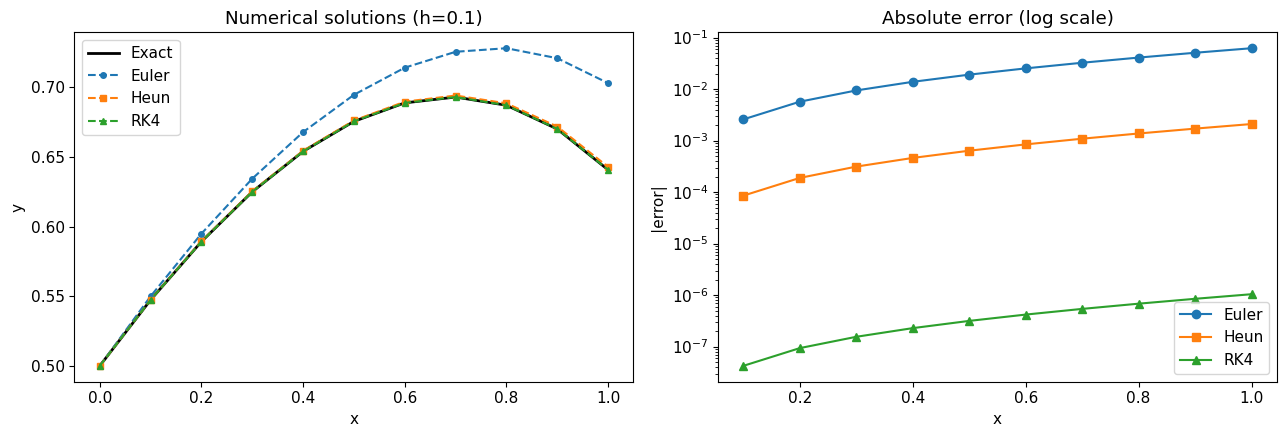

Error at x=1:  Euler=0.062270  Heun=0.002100  RK4=1.04e-06


In [6]:
# Example 4: Numerical methods comparison — Euler, Modified Euler, RK4
# IVP: y' = y - x, y(0) = 0.5   exact: y(x) = x + 1 - 0.5*e^x

def f(x, y):
    return y - x

def exact(x):
    return x + 1 - 0.5 * np.exp(x)

h = 0.1
x_pts = np.arange(0, 1 + h/2, h)
n = len(x_pts)

# Euler
y_euler = np.zeros(n)
# y(0) = 0.5
y_euler[0] = 0.5
for i in range(n - 1):
    y_euler[i+1] = y_euler[i] + h * f(x_pts[i], y_euler[i])

# Modified Euler (Heun)
y_heun = np.zeros(n)
y_heun[0] = 0.5
for i in range(n - 1):
    y_pred = y_heun[i] + h * f(x_pts[i], y_heun[i])
    y_heun[i+1] = y_heun[i] + 0.5 * h * (f(x_pts[i], y_heun[i]) + f(x_pts[i+1], y_pred))

# RK4
y_rk4 = np.zeros(n)
y_rk4[0] = 0.5
for i in range(n - 1):
    k1 = h * f(x_pts[i], y_rk4[i])
    k2 = h * f(x_pts[i] + 0.5*h, y_rk4[i] + 0.5*k1)
    k3 = h * f(x_pts[i] + 0.5*h, y_rk4[i] + 0.5*k2)
    k4 = h * f(x_pts[i+1], y_rk4[i] + k3)
    y_rk4[i+1] = y_rk4[i] + (k1 + 2*k2 + 2*k3 + k4) / 6

y_true = exact(x_pts)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
ax1.plot(x_pts, y_true, 'k-', lw=2, label='Exact')
ax1.plot(x_pts, y_euler, 'o--', ms=4, label='Euler')
ax1.plot(x_pts, y_heun, 's--', ms=4, label='Heun')
ax1.plot(x_pts, y_rk4, '^--', ms=4, label='RK4')
ax1.set(xlabel='x', ylabel='y', title=f'Numerical solutions (h={h})')
ax1.legend()

ax2.semilogy(x_pts[1:], np.abs(y_euler[1:] - y_true[1:]), 'o-', label='Euler')
ax2.semilogy(x_pts[1:], np.abs(y_heun[1:] - y_true[1:]), 's-', label='Heun')
ax2.semilogy(x_pts[1:], np.abs(y_rk4[1:] - y_true[1:]), '^-', label='RK4')
ax2.set(xlabel='x', ylabel='|error|', title='Absolute error (log scale)')
ax2.legend()
plt.tight_layout()
plt.show()

print(f"Error at x=1:  Euler={abs(y_euler[-1]-y_true[-1]):.6f}  "
      f"Heun={abs(y_heun[-1]-y_true[-1]):.6f}  RK4={abs(y_rk4[-1]-y_true[-1]):.2e}")

---
## 第 2 章 — 矩阵与线性方程组

### 核心结论
- **矩阵乘法** $(AB)_{ij} = \sum_k a_{ik}b_{kj}$ — 一般不满足交换律。
- **转置（Transpose）：** $(AB)^T = B^T A^T$。
- **Gauss 消元** 将增广矩阵 $[A|b]$ 化为行阶梯形（Row-Echelon Form）。
- **逆矩阵：** $A^{-1}$ 存在当且仅当 $\det(A) \ne 0$。通过 $[A|I] \to [I|A^{-1}]$ 计算。
- **LU 分解（LU Factorization）：** $A = LU$，$L$ 为单位下三角矩阵，$U$ 为上三角矩阵。

In [23]:
# Example: Gaussian elimination and LU decomposition
from scipy.linalg import lu

A = np.array([[2, 1, -1],
              [-3, -1, 2],
              [-2, 1, 2]], dtype=float)
b = np.array([8, -11, -3], dtype=float)

# LU decomposition
P, L, U = lu(A)
print("P (permutation):")
print(P)
print("\nL (lower triangular):")
print(L)
print("\nU (upper triangular):")
print(U)
print("\nVerify PA = LU:", np.allclose(P @ A, L @ U))

# Solve Ax = b
x = np.linalg.solve(A, b)
print(f"\nSolution: x = {x}")
print(f"Verify: Ax = {A @ x}")

P (permutation):
[[0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]]

L (lower triangular):
[[ 1.          0.          0.        ]
 [ 0.66666667  1.          0.        ]
 [-0.66666667  0.2         1.        ]]

U (upper triangular):
[[-3.         -1.          2.        ]
 [ 0.          1.66666667  0.66666667]
 [ 0.          0.          0.2       ]]

Verify PA = LU: False

Solution: x = [ 2.  3. -1.]
Verify: Ax = [  8. -11.  -3.]


---
## 第 3 章 — 行列式

### 定义（沿第 $i$ 行的 Cofactor 展开）
$$\det(A) = \sum_{j=1}^n a_{ij}\,C_{ij}, \quad C_{ij} = (-1)^{i+j}\,M_{ij}$$
其中 $M_{ij}$ 是去掉第 $i$ 行第 $j$ 列后的子矩阵的行列式（余子式）。

### Cofactor 展开的意义

行列式衡量的是一个线性变换对面积、体积或高维体积的**缩放倍数**，并带有方向符号。Cofactor 展开可以理解成：把这个高维体积沿某一行或某一列拆开，变成若干个“当前元素 $\times$ 剩余方向形成的低一维体积”的和。

也就是说，在
$$\det(A)=\sum_{j=1}^n a_{ij}C_{ij}$$
里面，$a_{ij}$ 是当前行里的一个元素，$C_{ij}$ 是它在整个行列式里的**权重**：如果只改变 $a_{ij}$，行列式会按这个权重变化。更精确地说，其他元素固定时：
$$C_{ij}=\frac{\partial \det(A)}{\partial a_{ij}}$$

所以 cofactor 不只是一个计算技巧，它有三层用处：
1. 把大矩阵行列式递归拆成小矩阵行列式；
2. 说明某个元素对整体体积缩放量的贡献权重；
3. 构造伴随矩阵和逆矩阵：$A^{-1}=\frac{1}{\det(A)}\operatorname{adj}(A)$。

实际数值计算大矩阵行列式时通常不用 cofactor 展开，因为它很慢；更常用 Gaussian elimination 或 LU decomposition。Cofactor 更重要的价值是理论理解：它解释了行列式如何按一行/列拆成低维贡献。

### 关键性质
1. $\det(A^T) = \det(A)$
2. 交换两行，行列式变号。
3. $\det(AB) = \det(A)\det(B)$
4. $A$ 可逆 $\iff \det(A) \ne 0$。
5. $\det(kA) = k^n \det(A)$（$A$ 为 $n \times n$ 矩阵）。

**Cramer 法则：** 对 $Ax = b$，$x_j = \det(A_j)/\det(A)$，其中 $A_j$ 是把 $A$ 的第 $j$ 列替换为 $b$ 得到的矩阵。

In [7]:
# Example: Cramer's Rule for a 3x3 system
A = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 0]], dtype=float)
b = np.array([6, 15, 15], dtype=float)

det_A = np.linalg.det(A)
print(f"det(A) = {det_A:.4f}")

x_cramer = np.zeros(3)
for j in range(3):
    A_j = A.copy()
    A_j[:, j] = b
    x_cramer[j] = np.linalg.det(A_j) / det_A

print(f"Cramer's rule: x = {x_cramer}")
print(f"np.linalg.solve: x = {np.linalg.solve(A, b)}")

det(A) = 27.0000
Cramer's rule: x = [1. 1. 1.]
np.linalg.solve: x = [1. 1. 1.]


---
## 第 4 章 — 向量空间

### 定义
**向量空间（Vector Space）** $V$（定义在 $\mathbb{R}$ 上）满足加法和标量乘法封闭，以及 8 条公理（结合律、交换律、零元素、逆元素等）。

- **子空间（Subspace）：** 非空子集，对 $+$ 和标量 $\cdot$ 封闭。
- **张成（Span）：** $\text{span}(\{v_1, \ldots, v_k\}) = \{c_1 v_1 + \cdots + c_k v_k\}$。
- **线性无关：** $c_1 v_1 + \cdots + c_k v_k = 0 \implies c_i = 0 \; \forall i$。
- **基（Basis）：** 线性无关的张成集。**维数（Dimension）** = 基向量个数。

### Rank-Nullity 定理
对 $A \in \mathbb{R}^{m \times n}$：
$$\text{rank}(A) + \text{nullity}(A) = n$$

### 矩阵的四个基本子空间

任何 $A \in \mathbb{R}^{m\times n}$ 都自带四个**基本子空间**，它们分布在 $\mathbb{R}^n$（输入侧）和 $\mathbb{R}^m$ （输出侧）两个母空间里：

| 子空间 | 记号 | 定义 | 所在母空间 | 维数 |
|--------|------|------|------------|------|
| **列空间**（值域 Range） | $\text{Col}(A)$ | $\{Ax : x\in\mathbb{R}^n\}$，$A$ 各列的张成 | $\mathbb{R}^m$ | $r$ |
| **零空间**（核 Kernel） | $\text{Null}(A)$ | $\{x : Ax = 0\}$ | $\mathbb{R}^n$ | $n-r$ |
| **行空间** | $\text{Row}(A) = \text{Col}(A^T)$ | $A$ 各行的张成 | $\mathbb{R}^n$ | $r$ |
| **左零空间** | $\text{Null}(A^T)$ | $\{y : A^T y = 0\}$，等价于 $y^T A = 0$ | $\mathbb{R}^m$ | $m-r$ |

其中 $r = \text{rank}(A)$。注意行空间和列空间的维数都是 $r$，这就是“行秩 = 列秩”的几何解释。

**正交关系（Fundamental Theorem of Linear Algebra）：** 在各自的母空间里，这四个子空间两两成正交补：
$$\text{Null}(A) \perp \text{Row}(A) \quad\text{在 } \mathbb{R}^n \text{ 中}$$
$$\text{Null}(A^T) \perp \text{Col}(A) \quad\text{在 } \mathbb{R}^m \text{ 中}$$
即在输入侧 $\mathbb{R}^n$，行空间和零空间互为正交补，维数加起来正好是 $n$（这就是 Rank-Nullity 定理的几何版）；在输出侧 $\mathbb{R}^m$，列空间和左零空间互为正交补，维数加起来是 $m$。

**直觉：** 把 $A$ 看成 $\mathbb{R}^n \to \mathbb{R}^m$ 的线性映射：
- 输入空间 $\mathbb{R}^n$ 被切成两块——行空间是“能影响输出的方向”，零空间是“被压成 0 的方向”；
- 输出空间 $\mathbb{R}^m$ 也被切成两块——列空间是“$A$ 能到达的方向”，左零空间是“$A$ 永远到不了的方向”。

**和方程 $Ax=b$ 的联系：**
- $b \in \text{Col}(A)$ 时方程有解；不然方程无解（这时最小二乘是退而求其次的方法）。
- 若 $\hat{x}$ 是一个解，那么所有解都是 $\hat{x} + \text{Null}(A)$，即在零空间里平移依然是解。


In [ ]:
# Example: rank, nullity, and null space
A = np.array([[1, 2, 3, 4],
              [2, 4, 6, 8],
              [1, 3, 5, 7]], dtype=float)

rank = np.linalg.matrix_rank(A)
n = A.shape[1]
nullity = n - rank

# SVD-based null space
U, S, Vt = np.linalg.svd(A)
# All input vectors that A maps to 0 (basis of the null space)
null_space = Vt[rank:].T

print(f"A (shape {A.shape}):")
print(A)
print(f"\nrank = {rank}, nullity = {nullity}, n = {n}")
print(f"rank + nullity = {rank + nullity} = n  ✓")
print(f"\nNull space basis (columns):")
print(null_space)
print(f"\nVerify A @ null_vec ≈ 0:")
for i in range(null_space.shape[1]):
    print(f"  A @ v{i+1} = {A @ null_space[:, i]}")

A (shape (3, 4)):
[[1. 2. 3. 4.]
 [2. 4. 6. 8.]
 [1. 3. 5. 7.]]

rank = 2, nullity = 2, n = 4
rank + nullity = 4 = n  ✓

Null space basis (columns):
[[ 0.54526074 -0.05187218]
 [-0.68835108  0.47557627]
 [-0.25908007 -0.79553599]
 [ 0.4021704   0.3718319 ]]

Verify A @ null_vec ≈ 0:
  A @ v1 = [-8.88178420e-16 -1.77635684e-15  6.10622664e-16]
  A @ v2 = [4.44089210e-16 8.88178420e-16 6.66133815e-16]



### 基变换（Change of Basis）

**场景：** 同一个向量 $x$，在不同基下有不同的坐标。基变换就是在两组坐标之间转换。

设 **老基** $B = \{v_1, \ldots, v_n\}$，**新基** $B' = \{v_1', \ldots, v_n'\}$。

**过渡矩阵 $S$（从 $B'$ 到 $B$）的构造：** 把新基的每个向量用老基表示，得到的系数排成列：

$$v_j' = s_{1j}\,v_1 + s_{2j}\,v_2 + \cdots + s_{nj}\,v_n$$

即 $S$ 的**第 $j$ 列** = 新基向量 $v_j'$ 在老基 $B$ 下的坐标 $[v_j']_B$：

$$S = \Big[\,[v_1']_B \;\Big|\; [v_2']_B \;\Big|\; \cdots \;\Big|\; [v_n']_B\,\Big]$$

**$S$ 的意义：** $S$ 不是直接改变向量本身，而是把"新基下的坐标"翻译成"老基下的坐标"。

为什么 $S$ 的列是新基向量在老基下的坐标？因为如果 $[x]_{B'} = (c_1, \ldots, c_n)^T$，按定义就是
$$x = c_1 v_1' + c_2 v_2' + \cdots + c_n v_n'$$
即 $x$ 是新基向量的线性组合，系数就是 $[x]_{B'}$。

把每个 $v_j'$ 用老基坐标 $[v_j']_B$ 替代，然后整体写成矩阵形式，就得到
$$[x]_B = c_1\,[v_1']_B + c_2\,[v_2']_B + \cdots + c_n\,[v_n']_B = S\,[x]_{B'}$$

换句话说，$S\,[x]_{B'}$ 的几何含义是：用 $[x]_{B'}$ 里的系数把 $S$ 的各列做线性组合；而 $S$ 的各列正好是新基向量在老基下的坐标，所以组合结果就是 $x$ 在老基下的坐标。

这样就有坐标变换公式：
$$[x]_B = S\,[x]_{B'}$$

> 读法：已知 $x$ 在新基 $B'$ 下的坐标，左乘 $S$ 就得到 $x$ 在老基 $B$ 下的坐标。

**反方向：** 从老基到新基，用逆矩阵：$[x]_{B'} = S^{-1}\,[x]_B$。

**实际计算方法：** 如果两组基都用标准基 $E$ 的坐标给出（即已知 $v_i$ 和 $v_j'$ 的标准坐标），那么：

$$S = \underbrace{[\,v_1 \mid \cdots \mid v_n\,]^{-1}}_{B\text{ 的坐标矩阵的逆}} \cdot \underbrace{[\,v_1' \mid \cdots \mid v_n'\,]}_{B'\text{ 的坐标矩阵}}$$

**具体例子：** $\mathbb{R}^2$ 中老基 $B = \{(1,0),\,(0,1)\}$（标准基），新基 $B' = \{(1,1),\,(1,-1)\}$。

$$S = I^{-1} \begin{pmatrix}1 & 1\\1 & -1\end{pmatrix} = \begin{pmatrix}1 & 1\\1 & -1\end{pmatrix}$$

向量 $x$ 若在新基下坐标为 $[x]_{B'} = (3, 2)^T$，则标准坐标 $[x]_B = S\,(3,2)^T = (5, 1)^T$。

验证：$3 \cdot (1,1) + 2 \cdot (1,-1) = (5, 1)$ ✓

In [8]:
# Example: change of basis in R^2
# old B = standard basis {(1,0), (0,1)}
# new B' = {(1,1), (1,-1)}
B  = np.eye(2)
Bp = np.array([[1.0, 1.0],
               [1.0, -1.0]])

S = np.linalg.inv(B) @ Bp

x_in_Bp = np.array([3.0, 2.0])
x_in_B  = S @ x_in_Bp

x_back = np.linalg.inv(S) @ x_in_B

print("S (new -> old):")
print(S)
print(f"\n[x]_B'  = {x_in_Bp}")
print(f"[x]_B   = S @ [x]_B'  = {x_in_B}")
print(f"verify: 3*(1,1) + 2*(1,-1) = {3*Bp[:,0] + 2*Bp[:,1]}")

print(f"\n[x]_B' = S^-1 @ [x]_B = {x_back}  (should match {x_in_Bp})")

S (new -> old):
[[ 1.  1.]
 [ 1. -1.]]

[x]_B'  = [3. 2.]
[x]_B   = S @ [x]_B'  = [5. 1.]
verify: 3*(1,1) + 2*(1,-1) = [5. 1.]

[x]_B' = S^-1 @ [x]_B = [3. 2.]  (should match [3. 2.])


---
## 第 5 章 — 内积空间

### 定义
向量空间 $V$ 上的 **内积(Inner Product)** 是映射 $\langle \cdot, \cdot \rangle: V \times V \to \mathbb{R}$，满足：
1. $\langle u, v \rangle = \langle v, u \rangle$（对称性）
2. $\langle u + v, w \rangle = \langle u, w \rangle + \langle v, w \rangle$（可加性）
3. $\langle cu, v \rangle = c\langle u, v \rangle$（齐次性）
4. $\langle v, v \rangle \ge 0$，等号成立当且仅当 $v = 0$（正定性）

$\mathbb{R}^n$ 上的标准内积：$\langle x, y \rangle = x^T y$。

### Gram-Schmidt 正交化
给定 $\{v_1, \ldots, v_k\}$，生成正交集 $\{u_1, \ldots, u_k\}$：
$$u_1 = v_1, \quad u_j = v_j - \sum_{i=1}^{j-1} \frac{\langle v_j, u_i\rangle}{\langle u_i, u_i\rangle} u_i$$

### 最小二乘（Least Squares）

**问题：** 当 $Ax = b$ 无精确解时（方程比未知数多，即 overdetermined system），我们想找一个 $\hat{x}$ 使得残差 $\|Ax - b\|^2$ 最小。

**几何直觉：** $b$ 不在 $A$ 的列空间 $\text{Col}(A)$ 里，所以 $Ax$ 永远不能等于 $b$。最好的近似是把 $b$ 正交投影到 $\text{Col}(A)$ 上，投影点就是 $A\hat{x}$。

**推导：** 残差向量 $b - A\hat{x}$ 必须与 $A$ 的每一列正交（投影的定义），即：

$$A^T(b - A\hat{x}) = 0 \quad \Longrightarrow \quad A^T A\,\hat{x} = A^T b$$

这就是**正规方程（Normal Equations）**。它之所以叫"正规"，是因为条件就是残差 **normal（垂直）** 于列空间。

**典型应用：** 线性回归。有 $m$ 个数据点要拟合 $y = a + bx$，写成矩阵形式就是 overdetermined 的 $Ax = b$（$m$ 行 2 列），正规方程一步求出最佳拟合系数。

Orthonormal basis Q:
[[ 0.70710678  0.40824829 -0.57735027]
 [ 0.70710678 -0.40824829  0.57735027]
 [ 0.          0.81649658  0.57735027]]

Q^T Q = 
[[1.00000000e+00 2.45142679e-17 2.73204007e-17]
 [2.45142679e-17 1.00000000e+00 9.80784505e-17]
 [2.73204007e-17 9.80784505e-17 1.00000000e+00]]  (should be I)


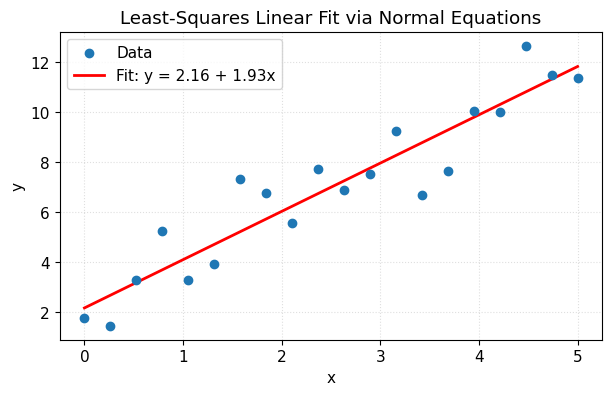

In [9]:
# Example: Gram-Schmidt orthogonalization
def gram_schmidt(V):
    """V: list of column vectors (numpy arrays). Returns orthonormal list."""
    U = []
    for v in V:
        u = v.copy().astype(float)
        for uj in U:
            u -= np.dot(u, uj) / np.dot(uj, uj) * uj
        U.append(u)
    return [u / np.linalg.norm(u) for u in U]

v1 = np.array([1, 1, 0])
v2 = np.array([1, 0, 1])
v3 = np.array([0, 1, 1])

Q = gram_schmidt([v1, v2, v3])
Q_mat = np.column_stack(Q)
print("Orthonormal basis Q:")
print(Q_mat)
print(f"\nQ^T Q = \n{Q_mat.T @ Q_mat}  (should be I)")

# Least-squares fit: y = a + bx to noisy data
np.random.seed(42)
x_data = np.linspace(0, 5, 20)
y_data = 2.5 * x_data + 1.0 + np.random.randn(20) * 1.5

A_ls = np.column_stack([np.ones_like(x_data), x_data])
x_hat = np.linalg.solve(A_ls.T @ A_ls, A_ls.T @ y_data)

plt.figure(figsize=(7, 4))
plt.scatter(x_data, y_data, label='Data', zorder=5)
plt.plot(x_data, x_hat[0] + x_hat[1] * x_data, 'r-', lw=2,
         label=f'Fit: y = {x_hat[0]:.2f} + {x_hat[1]:.2f}x')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Least-Squares Linear Fit via Normal Equations')
plt.legend()
plt.grid(True, ls=':', alpha=0.4)
plt.show()

---
## 第 6 章 — 线性变换

### 定义
映射 $T: V \to W$ 是**线性变换（Linear Transformation）**，如果：
$$T(u+v) = T(u) + T(v), \quad T(cv) = cT(v)$$

### Kernel 与 Range
- $\text{Ker}(T) = \{v \in V : T(v) = 0\}$ — $V$ 的子空间（即零空间）。
- $\text{Rng}(T) = \{T(v) : v \in V\}$ — $W$ 的子空间（即值域/像）。
- **维数定理：** $\dim(\text{Ker}(T)) + \dim(\text{Rng}(T)) = \dim(V)$。

### 矩阵表示
若 $V$ 的基为 $B = \{v_1, \ldots, v_n\}$，$W$ 的基为 $B'$，则 $T$ 对应矩阵 $A$，其第 $j$ 列是 $[T(v_j)]_{B'}$。

### $\mathbb{R}^2$ 上的标准变换
| 变换 | 矩阵 |
|------|------|
| 旋转 $\theta$ 角 | $\begin{pmatrix}\cos\theta & -\sin\theta \\ \sin\theta & \cos\theta\end{pmatrix}$ |
| 关于 $x$ 轴反射 | $\begin{pmatrix}1 & 0 \\ 0 & -1\end{pmatrix}$ |
| 缩放 $(s_x, s_y)$ | $\begin{pmatrix}s_x & 0 \\ 0 & s_y\end{pmatrix}$ |
| 水平剪切 | $\begin{pmatrix}1 & k \\ 0 & 1\end{pmatrix}$ |

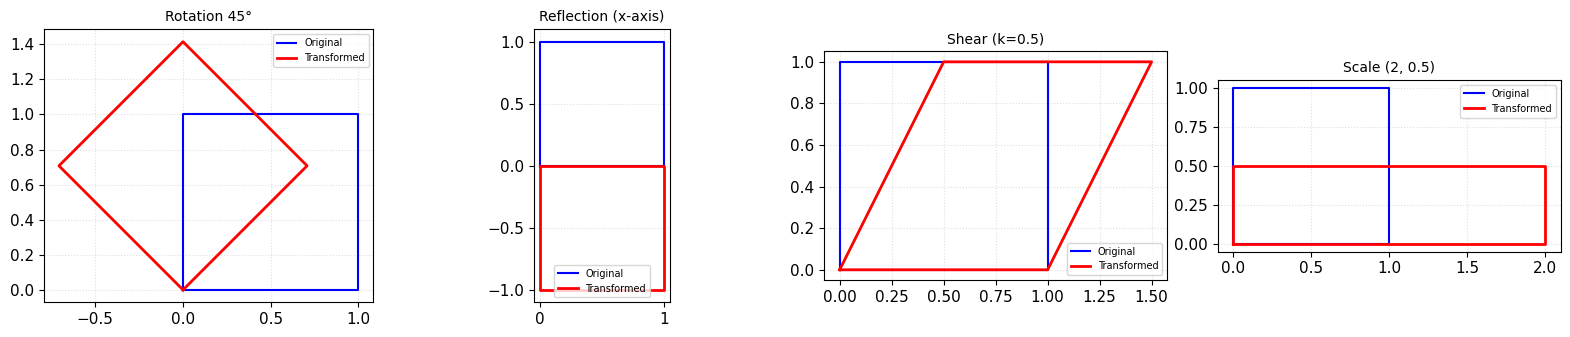

In [27]:
# Visualize 2D linear transformations on a unit square
square = np.array([[0,0],[1,0],[1,1],[0,1],[0,0]]).T  # 2 x 5

theta = np.pi / 4
transforms = {
    f'Rotation {np.degrees(theta):.0f}°': np.array([[np.cos(theta), -np.sin(theta)],
                                                     [np.sin(theta),  np.cos(theta)]]),
    'Reflection (x-axis)': np.array([[1, 0], [0, -1]]),
    'Shear (k=0.5)': np.array([[1, 0.5], [0, 1]]),
    'Scale (2, 0.5)': np.array([[2, 0], [0, 0.5]]),
}

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, (name, M) in zip(axes, transforms.items()):
    transformed = M @ square
    ax.plot(*square, 'b-', lw=1.5, label='Original')
    ax.plot(*transformed, 'r-', lw=2, label='Transformed')
    ax.set_aspect('equal')
    ax.set_title(name, fontsize=10)
    ax.grid(True, ls=':', alpha=0.4)
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

---
## 第 7 章 — 特征值与特征向量

### 特征值问题（Eigenvalue Problem）
$$Av = \lambda v, \quad v \ne 0$$

**特征方程（Characteristic Equation）：** $\det(A - \lambda I) = 0$。

### 对角化（Diagonalization）
若 $A$ 有 $n$ 个线性无关的 eigenvector $v_1, \ldots, v_n$，对应 eigenvalue $\lambda_1, \ldots, \lambda_n$，则：
$$A = S D S^{-1}, \quad S = [v_1 | \cdots | v_n], \quad D = \text{diag}(\lambda_1, \ldots, \lambda_n)$$

**矩阵幂：** $A^k = S D^k S^{-1}$。

### Matrix Exponential

**目标：** 求线性常微分方程组
$$\dot{x} = Ax, \quad x(0) = x_0$$
的解，其中 $x(t)\in\mathbb{R}^n$，$A$ 是 $n\times n$ 矩阵。

**类比标量情况：** 标量方程 $\dot x = ax$ 的解是 $x(t)=e^{at}x_0$。把 $a$ 换成矩阵 $A$，能不能写成 $x(t)=e^{At}x_0$？可以，前提是先定义"矩阵的指数"是什么。

**矩阵指数的定义（泰勒级数）：**
$$e^{At} = I + At + \frac{(At)^2}{2!} + \frac{(At)^3}{3!} + \cdots$$
直接按级数算很麻烦，所以更常用下面的对角化版本。

**对角化版本来历**（$A$ 可对角化时）:
$$e^{At} = S\, \text{diag}(e^{\lambda_1 t}, \ldots, e^{\lambda_n t})\, S^{-1}$$

利用 $A=SDS^{-1}$，有 $A^k=SD^kS^{-1}$，代回级数得
$$e^{At} = S\,e^{Dt}\,S^{-1} = S\,\text{diag}(e^{\lambda_1 t}, \ldots, e^{\lambda_n t})\,S^{-1}$$
（对角矩阵的指数就是各对角元分别取指数）

**解形式验证：** 把级数对 $t$ 求导得 $\dfrac{d}{dt}e^{At}=A\,e^{At}$，所以
$$\dot x = A\,e^{At}x_0 = Ax$$
并且 $x(0)=e^{0}x_0=x_0$，初值条件成立。

**几何直觉（坐标变换的视角）：** 公式 $S\,\text{diag}(e^{\lambda_i t})\,S^{-1}$ 可以分三步读：
1. $S^{-1}$：把 $x_0$ 翻译成**特征向量基**下的坐标；
2. $\text{diag}(e^{\lambda_i t})$：每个分量沿对应特征方向独立按 $e^{\lambda_i t}$ 演化；
3. $S$：再翻译回原来的标准坐标。

也就是说，$A$ 在它"自己的特征向量基"下变成对角矩阵，每个独立模态按各自的 $e^{\lambda_i t}$ 演化，再变换回原坐标系。

**和稳定性的关系：** 特征值 $\lambda_i$ 直接告诉解的走向：
- $\text{Re}(\lambda_i)<0$：该方向上的解随 $t$ 衰减到 $0$（稳定）；
- $\text{Re}(\lambda_i)>0$：该方向指数增长（不稳定）；
- $\lambda_i$ 是复数：会出现旋转/振荡。

### 正交对角化（对称矩阵）
若 $A = A^T$（对称），则 $A$ 有实 eigenvalue 和正交归一的 eigenvector 基：
$$A = Q \Lambda Q^T, \quad Q^T Q = I$$

### Jordan 标准形

**问题背景：** 不是所有矩阵都能对角化。当 eigenvalue 的代数重数 > 几何重数（即 eigenvector 不够多）时，$A$ **不可对角化**。Jordan 标准形就是处理这种情况的工具。

**Jordan Block：** 一个 $k \times k$ 的 Jordan Block $J_k(\lambda)$ 长这样——对角线上全是 $\lambda$，上方紧贴对角线的位置全是 1，其余全是 0：

$$J_k(\lambda) = \begin{pmatrix} \lambda & 1 & 0 & \cdots & 0 \\ 0 & \lambda & 1 & \cdots & 0 \\ \vdots & & \ddots & \ddots & \vdots \\ 0 & 0 & \cdots & \lambda & 1 \\ 0 & 0 & \cdots & 0 & \lambda \end{pmatrix}_{k \times k}$$

例如 $J_1(3) = (3)$，$J_2(3) = \begin{pmatrix}3 & 1 \\ 0 & 3\end{pmatrix}$，$J_3(3) = \begin{pmatrix}3 & 1 & 0 \\ 0 & 3 & 1 \\ 0 & 0 & 3\end{pmatrix}$。

**Jordan 标准形定理：** 任意方阵 $A$ 都相似于一个 Jordan 矩阵：
$$J = P^{-1}AP = \text{diag}(J_{k_1}(\lambda_1), \; J_{k_2}(\lambda_2), \; \ldots)$$

即 $J$ 是若干 Jordan Block 沿对角线排列组成的分块对角矩阵。

**直观理解：**
- 如果 $A$ 可对角化，那么所有 Jordan Block 都是 $1 \times 1$ 的，Jordan 标准形就退化为对角矩阵。
- 如果某个 eigenvalue $\lambda$ 的 eigenvector 不足，就会出现大于 $1 \times 1$ 的 Jordan Block。Block 越大，说明该 eigenvalue 方向上的"缺陷"越严重。

**作用与意义：**
1. **矩阵指数：** $e^{J_k(\lambda)t}$ 有显式公式——会出现 $t, t^2, \ldots$ 乘以 $e^{\lambda t}$ 的项，这解释了为什么不可对角化系统的解中会有 $te^{\lambda t}$ 这样的项。
2. **ODE 系统：** 对 $\dot{x} = Ax$，Jordan 标准形告诉我们解的完整结构，包括"广义 eigenvector"对应的 $t^j e^{\lambda t}$ 分量。

### 对称矩阵正交对角化与二次型可视化

下面的代码演示了**对称矩阵的正交对角化**以及它和**二次型 $f(x) = x^T A x$** 的几何关系，对应正文里的“正交对角化”一节：
$$A = Q\Lambda Q^T,\quad Q^T Q = I$$

具体在做这几件事：

1. **构造对称矩阵 $A=\begin{pmatrix}5 & 2 \\ 2 & 2\end{pmatrix}$**，并用 `np.linalg.eigh` 做正交对角化。`eigh` 是专门给对称/Hermitian 矩阵的版本，保证特征值实数、特征向量正交，并验证 $Q^T Q = I$。
2. **把二次型 $f(x,y) = 5x^2 + 4xy + 2y^2$ 当作高度场，在 $(x,y)$ 平面上画等高线**。对正定对称矩阵，等高线是**椭圆**；红色箭头是两列特征向量，正好沿着椭圆的长短轴方向。
3. **右图：在特征基下重画 $f = \lambda_1 u_1^2 + \lambda_2 u_2^2$**。坐标变换 $u = Q^T x$ 把交叉项 $4xy$ 完全消掉，椭圆的轴变成与坐标轴对齐。

**核心点：** 对称矩阵的对角化就是“**找一组旋转过的坐标轴，让二次型只剩平方项**”，这组新坐标轴方向就是特征向量。这也是 PCA、Gaussian 协方差椭圆、Hessian 分析等 ML 概念的几何基础。


A = [[5.0, 2.0], [2.0, 2.0]]
Eigenvalues: [1. 6.]
Q^T Q = I? True


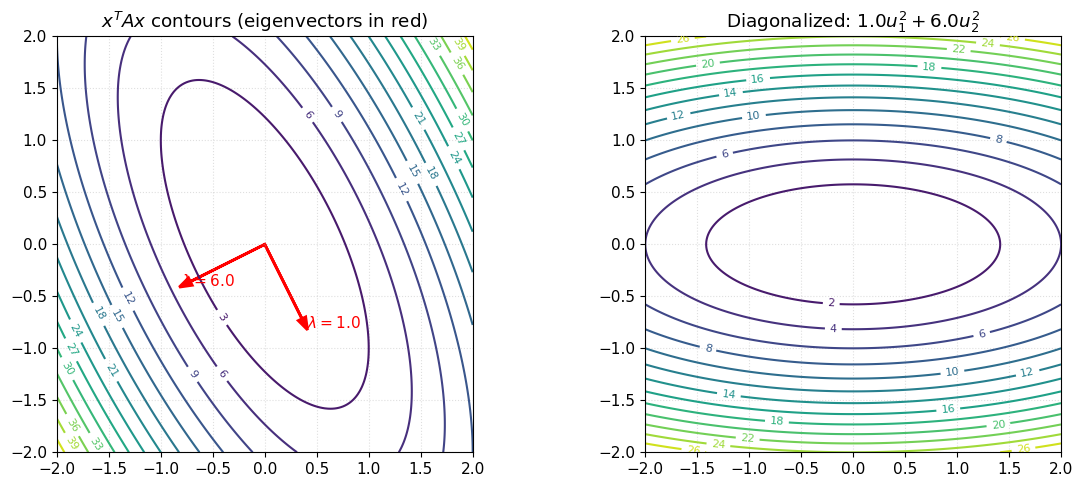

In [15]:
# Symmetric matrix diagonalization and quadratic form visualization
A_sym = np.array([[5, 2], [2, 2]], dtype=float)
lam, Q = np.linalg.eigh(A_sym)
print(f"A = {A_sym.tolist()}")
print(f"Eigenvalues: {lam}")
print(f"Q^T Q = I? {np.allclose(Q.T @ Q, np.eye(2))}")

# Quadratic form: f(x) = x^T A x
x = np.linspace(-2, 2, 200)
y = np.linspace(-2, 2, 200)
X, Y = np.meshgrid(x, y)
Z = A_sym[0,0]*X**2 + 2*A_sym[0,1]*X*Y + A_sym[1,1]*Y**2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
cs = ax1.contour(X, Y, Z, levels=15)
ax1.clabel(cs, fontsize=8)
for i in range(2):
    ax1.arrow(0, 0, Q[0,i]*0.8, Q[1,i]*0.8, head_width=0.08, color='red', lw=2)
    ax1.text(Q[0,i]*0.9, Q[1,i]*0.9, f'$\\lambda={lam[i]:.1f}$', color='red', fontsize=11)
ax1.set_aspect('equal')
ax1.set_title('$x^T A x$ contours (eigenvectors in red)')
ax1.grid(True, ls=':', alpha=0.4)

# In eigenbasis, the quadratic form is diagonal
Z_diag = lam[0]*X**2 + lam[1]*Y**2
cs2 = ax2.contour(X, Y, Z_diag, levels=15)
ax2.clabel(cs2, fontsize=8)
ax2.set_aspect('equal')
ax2.set_title(f'Diagonalized: ${lam[0]:.1f}u_1^2 + {lam[1]:.1f}u_2^2$')
ax2.grid(True, ls=':', alpha=0.4)
plt.tight_layout()
plt.show()

### Phase Portrait 和稳定性

**Phase portrait（相图 / 相轨迹图）** 是动力系统 $\dot x = Ax$（或非线性系统 $\dot x = F(x)$）在**状态空间**里的可视化方式。

- **状态空间**：把 $x$ 的所有分量当作坐标轴，整个空间叫状态空间（state space）/ 相空间（phase space）。对二维系统就是 $x_1$-$x_2$ 平面。
- **相轨迹（trajectory）**：从某个初值 $x_0$ 出发，随时间演化得到的曲线 $\{x(t):t\ge 0\}$ 在状态空间里画出的路径。注意时间 $t$ 不出现在坐标轴上，它沿曲线“流”下去；同一条曲线上每一点对应不同时刻的状态。
- **Phase portrait**：把多个不同初值出发的相轨迹画在同一张图上，整体反映系统的动力学结构（吸引、排斥、旋转、鞍形等）。

下面这段代码做的是：
1. 在半径为 2 的圆上均匀取 20 个初值 $x_0$；
2. 对每个 $x_0$，沿 $t\in[0,5]$ 用 $x(t)=e^{At}x_0$ 计算解；
3. 把这 20 条 $x(t)$ 在 $(x_1,x_2)$ 平面上画出来，得到 phase portrait。

**图像解读：**
- 所有曲线最终趋向哪里 → 那里是吸引子 / 稳定平衡点；
- 曲线“逃离”某点 → 那里是不稳定平衡点；
- 曲线绕某点旋转 → 复数特征值（振荡），实部决定螺旋向内还是向外；
- 一条曲线的形状反映 $A$ 的特征值/特征向量结构（特征向量方向是“直线轨迹”的方向）。

右边那张图画的是算子范数 $\|e^{At}\|_2$ 随 $t$ 的变化，相当于“最坏情况下解被放大多少倍”，可以快速看出系统是衰减还是发散。

A =
[[ 0.  1.]
 [-2. -3.]]

Eigenvalues: [-1. -2.]
Eigenvectors (columns):
[[ 0.70710678 -0.4472136 ]
 [-0.70710678  0.89442719]]

S D S^(-1) = A? True


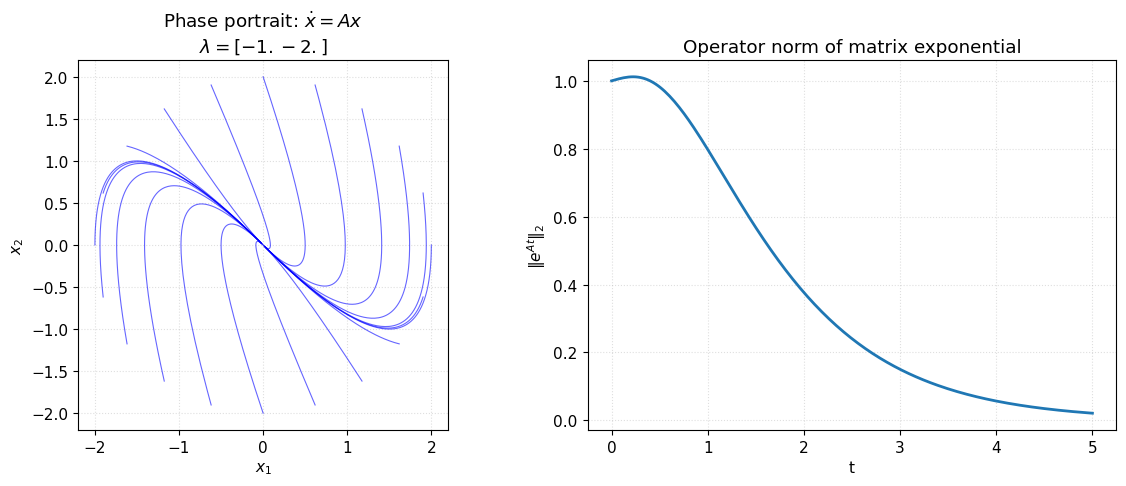

In [ ]:

from scipy.linalg import expm
# Example: Eigendecomposition and matrix exponential
A = np.array([[0, 1], [-2, -3]], dtype=float)

eigenvalues, eigenvectors = np.linalg.eig(A)
print("A =")
print(A)
print(f"\nEigenvalues: {eigenvalues}")
print(f"Eigenvectors (columns):\n{eigenvectors}")

# Verify diagonalization: A = S D S^{-1}
S = eigenvectors
D = np.diag(eigenvalues)
A_reconstructed = S @ D @ np.linalg.inv(S)
print(f"\nS D S^(-1) = A? {np.allclose(A, A_reconstructed)}")

# Phase portrait: dx/dt = Ax
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Trajectories
t_span = np.linspace(0, 5, 200)
for angle in np.linspace(0, 2*np.pi, 20, endpoint=False):
    x0 = 2 * np.array([np.cos(angle), np.sin(angle)])
    # matrix exponential expm(M) = I + M + M^2/2! + M^3/3! + ...
    # expand by taylor series for t in t_span
    traj = np.array([expm(A * t) @ x0 for t in t_span])
    ax1.plot(traj[:, 0], traj[:, 1], 'b-', lw=0.8, alpha=0.6)

ax1.set_aspect('equal')
ax1.set(xlabel='$x_1$', ylabel='$x_2$', title=f'Phase portrait: $\\dot{{x}} = Ax$\n$\\lambda = {eigenvalues}$')
ax1.grid(True, ls=':', alpha=0.4)

# e^{At} norms over time
norms = [np.linalg.norm(expm(A * t), 2) for t in t_span]
ax2.plot(t_span, norms, lw=2)
ax2.set(xlabel='t', ylabel='$\\|e^{At}\\|_2$', title='Operator norm of matrix exponential')
ax2.grid(True, ls=':', alpha=0.4)

plt.tight_layout()
plt.show()

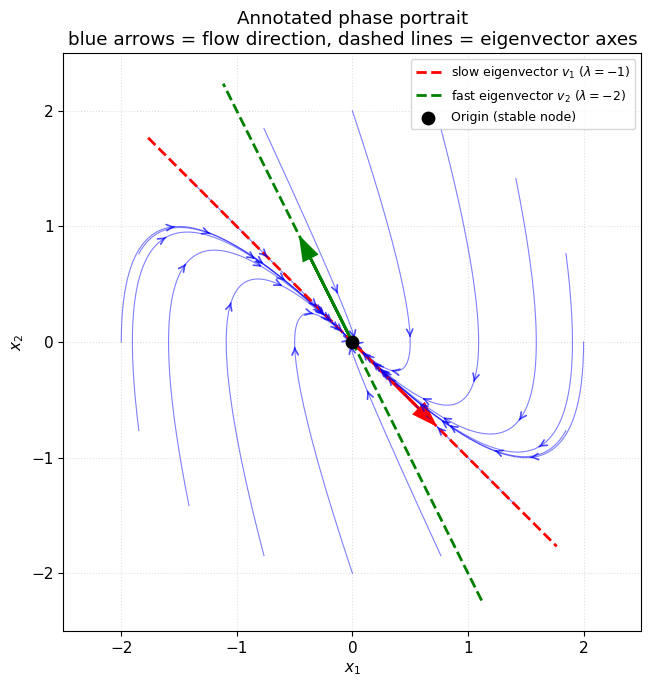

In [14]:
# Annotated phase portrait: arrows for flow direction + eigenvector lines
A = np.array([[0, 1], [-2, -3]], dtype=float)
eigvals, eigvecs = np.linalg.eig(A)

order = np.argsort(np.abs(eigvals))
v_slow = eigvecs[:, order[0]]
v_fast = eigvecs[:, order[1]]
lam_slow = eigvals[order[0]]
lam_fast = eigvals[order[1]]

fig, ax = plt.subplots(figsize=(7, 7))

t_span = np.linspace(0, 5, 200)
for angle in np.linspace(0, 2*np.pi, 16, endpoint=False):
    x0 = 2 * np.array([np.cos(angle), np.sin(angle)])
    traj = np.array([expm(A * t) @ x0 for t in t_span])
    ax.plot(traj[:, 0], traj[:, 1], 'b-', lw=0.8, alpha=0.5)
    for k in [25, 60, 110]:
        ax.annotate('', xy=(traj[k+1, 0], traj[k+1, 1]),
                    xytext=(traj[k, 0], traj[k, 1]),
                    arrowprops=dict(arrowstyle='->', color='blue', lw=1.2, alpha=0.7))

s = np.linspace(-2.5, 2.5, 50)
ax.plot(v_slow[0]*s, v_slow[1]*s, 'r--', lw=2,
        label=f'slow eigenvector $v_1$ ($\\lambda={lam_slow:.0f}$)')
ax.plot(v_fast[0]*s, v_fast[1]*s, 'g--', lw=2,
        label=f'fast eigenvector $v_2$ ($\\lambda={lam_fast:.0f}$)')

ax.arrow(0, 0, v_slow[0]*1.0, v_slow[1]*1.0,
         head_width=0.12, color='red', lw=2, length_includes_head=True)
ax.arrow(0, 0, v_fast[0]*1.0, v_fast[1]*1.0,
         head_width=0.12, color='green', lw=2, length_includes_head=True)

ax.scatter([0], [0], color='black', s=80, zorder=5, label='Origin (stable node)')

ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)
ax.set_aspect('equal')
ax.set(xlabel='$x_1$', ylabel='$x_2$',
       title='Annotated phase portrait\nblue arrows = flow direction, dashed lines = eigenvector axes')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, ls=':', alpha=0.4)
plt.tight_layout()
plt.show()

**相图解读**

1. **蓝色小箭头 = 时间流动方向。** 标在每条蓝色轨迹上，指向 $t$ 增大的方向。所有箭头都指向原点，表明系统是稳定的（任何初值最终趋于原点）。
2. **红色虚线 = 慢特征向量 $v_1$ 的方向**（$\lambda_1=-1$）。phase portrait 上"曲线密集贴线"的那条线就是它。所有不在 $v_2$ 方向上的初值，最终都会"贴"到这条红线上滑向原点。
3. **绿色虚线 = 快特征向量 $v_2$ 的方向**（$\lambda_2=-2$）。如果初值正好落在这条线上，轨迹会沿它直接进原点；但因为 $e^{-2t}$ 衰减极快，沿绿线的轨迹"嗖一下就到了"。
4. **黑色实心点 = 原点**。它是 stable node，所有曲线最终都终结于此。

**直觉总结：**

$$x(t) = c_1 e^{\lambda_1 t} v_1 + c_2 e^{\lambda_2 t} v_2 = c_1 e^{-t} v_1 + c_2 e^{-2t} v_2$$

- **远离原点：** 两个模态都有显著贡献，曲线弯曲；
- **靠近原点：** 快模态 $e^{-2t}$ 已经几乎消失，曲线几乎只剩慢模态 $c_1 e^{-t} v_1$，所以"贴"到 $v_1$ 方向；
- **比较两个特征值的绝对值** 就能判断"快慢"，绝对值大的衰减快。

**和稳定性的关系：** stable node ⇔ 两个特征值都是实负数。如果其中一个是正的，就会变成 saddle（鞍点）；如果是复数对，就会变成 spiral（螺旋）。

---
## 第 8 章 — $n$ 阶线性微分方程

### 一般理论
$$a_0 y^{(n)} + a_1 y^{(n-1)} + \cdots + a_n y = F(x)$$

其中 $y^{(k)}$ 是 $y$ 的第 $k$ 阶导数，$a_i$ 是系数（常数或 $x$ 的函数），$F(x)$ 叫**强迫项 / 驱动项（forcing term）**，代表来自外部的输入。

#### 齐次 vs 非齐次

- **齐次方程（homogeneous）：** $F(x)\equiv 0$，方程退化为
  $$a_0 y^{(n)} + a_1 y^{(n-1)} + \cdots + a_n y = 0$$
  含义是“**没有外部输入，系统按自己的内在动力学演化**”。比如弹簧自由振动、被扰动后的自然衰减/振荡。
- **非齐次方程（non-homogeneous）：** $F(x)\ne 0$，含义是“**系统被某个外力持续推动**”，比如有人持续推弹簧、电路里有持续输入电压。

**线性方程通解结构：**
$$y = y_h + y_p$$
- $y_h$：**齐次解**，描述系统的内在自由演化；
- $y_p$：**特解**，描述对外力 $F$ 的响应。

所以总要先研究齐次解，因为它代表“扰动一下，系统会怎么自然回应”。

**叠加原理：** 若 $y_1, \ldots, y_n$ 是齐次方程（$F=0$）的解且线性无关（Wronskian $W \ne 0$），则齐次通解为 $y_h = c_1 y_1 + \cdots + c_n y_n$。

### 常系数齐次方程
特征方程：$a_0 r^n + a_1 r^{n-1} + \cdots + a_n = 0$。
- **不等实根** $r_1, \ldots, r_n$：$y = c_1 e^{r_1 x} + \cdots + c_n e^{r_n x}$
- **重根** $r$（重数 $k$）：$e^{rx}, xe^{rx}, \ldots, x^{k-1}e^{rx}$
- **共轭复根** $\alpha \pm \beta i$：$e^{\alpha x}\cos(\beta x)$ 和 $e^{\alpha x}\sin(\beta x)$

### 待定系数法（Undetermined Coefficients）
当 $F(x)$ 含 $e^{\alpha x}$、$\sin$、$\cos$、多项式时：猜一个与 $F$ 同形式的特解，代入方程解出系数。

---
**例：** 求

$$y''-3y'+2y=e^{3x}$$

的一个特解。因为右侧是 $e^{3x}$，设

$$y_p=Ae^{3x}$$

则

$$y_p'=3Ae^{3x},\qquad y_p''=9Ae^{3x}$$

代回左侧：

$$y_p''-3y_p'+2y_p=(9A-9A+2A)e^{3x}=2Ae^{3x}$$

令它等于右侧 $e^{3x}$，得到

$$2A=1\quad\Rightarrow\quad A=\frac12$$

所以一个特解是

$$y_p=\frac12 e^{3x}$$

待定系数法的关键在于：右侧函数形式较简单，可以预先设定特解的形式，再通过代入求出有限个未知系数。

---

### 参数变分法（Variation of Parameters）
$$y_p = \sum_{i=1}^n u_i(x)\, y_i(x), \quad u_i'(x) = \frac{W_i(x)}{W(x)} \cdot \frac{F(x)}{a_0}$$
其中 $W$ 是 Wronskian，$W_i$ 将第 $i$ 列替换为 $(0,\ldots,0,1)^T$。

对二阶标准形式

$$y''+p(x)y'+q(x)y=g(x)$$

若齐次方程有基本解 $y_1,y_2$，参数变分法设

$$y_p=u_1(x)y_1(x)+u_2(x)y_2(x)$$

其中

$$u_1'=-\frac{y_2g}{W},\qquad u_2'=\frac{y_1g}{W},\qquad W=y_1y_2'-y_2y_1'$$

---
**例：** 求

$$y''+y=\sec x$$

的一个特解。齐次方程 $y''+y=0$ 的基本解为

$$y_1=\cos x,\qquad y_2=\sin x$$

Wronskian 为

$$W=\cos x\cdot\cos x-\sin x\cdot(-\sin x)=1$$

这里 $g(x)=\sec x$，所以

$$u_1'=-\frac{y_2g}{W}=-\sin x\sec x=-\tan x$$

$$u_2'=\frac{y_1g}{W}=\cos x\sec x=1$$

积分得到

$$u_1=\int -\tan x\,dx=\ln|\cos x|,\qquad u_2=\int 1\,dx=x$$

因此一个特解是

$$y_p=u_1y_1+u_2y_2=\cos x\ln|\cos x|+x\sin x$$

参数变分法的优势在于：右侧 $g(x)$ 不必限于指数、三角函数或多项式；只要齐次解已知，就可以通过积分构造特解。

---

### 振动（弹簧-质量系统）
$$m y'' + b y' + k y = F(t)$$
- **无阻尼**（$b=0$）：$y = A\cos(\omega t - \phi)$，$\omega = \sqrt{k/m}$
- **欠阻尼**（$b^2 < 4mk$）：衰减振荡
- **临界阻尼**（$b^2 = 4mk$）：最快的非振荡衰减
- **过阻尼**（$b^2 > 4mk$）：指数衰减，无振荡


### Polyak Momentum 的方向性加速机制

上面的表里说 momentum「累积惯性：长轴方向同号叠加加速，短轴方向反号相消减振荡」。这一节展开解释——为什么同一条更新公式

$$v_{k+1} = \beta v_k + g_k,\qquad \theta_{k+1} = \theta_k - \eta\, v_{k+1}$$

会同时在两个方向上做出相反的事。

---

#### 1. 梯度符号一致性与动量累积

momentum 的核心更新

$$v_{k+1} = \beta v_k + g_k$$

是把过去的梯度按指数权重累加。所以最终 $v$ 的大小取决于一个简单的事实：

> 连续几步的 $g_k$ 是同向（叠加）还是反向（抵消）。

把 GD 的更新代入二次函数

$$L = \tfrac12 \lambda z^2$$

每个特征方向上

$$g_k = \lambda\, z_k$$

是一个一维标量。

> **标量二次模型的来源：** 在最优点附近 $L \approx \tfrac12 \delta^T H \delta$，对 $H = Q\Lambda Q^T$ 做正交对角化、令 $z = Q^T \delta$，损失被解耦成 $L(z) = \tfrac12 \sum_i \lambda_i z_i^2$，每个方向互不耦合。**抽出任意一个方向**、省略下标，就得到这里的标量形式 $L = \tfrac12 \lambda z^2$、$g_k = \lambda z_k$；下面的结论平行套到每个 $\lambda_i$ 上即可。

所以「同号 / 反号」可以直接看 $z_k$ 的轨迹。

---

#### 2. 短轴方向（大 $\lambda$，陡）

短轴方向「窄」——稍微走一点 $z$ 就接近 $0$ 甚至越过去。所以一个典型的 GD 步会冲过头。

取 $\lambda = 4$，$\eta = 0.5$。GD 在这个方向上的迭代公式是

$$z_{k+1} = (1-\eta\lambda)\, z_k$$

代入数值：

$$1 - \eta\lambda = 1 - 0.5\times 4 = -1\quad\Rightarrow\quad z_{k+1} = -\,z_k$$

从 $z_0 = 1$ 出发逐步算出下表（不是凭空给的数）：

| 步 $k$ | $z_k$ | $g_k = 4 z_k$ | 解释 |
|---|---|---|---|
| 0 | $+1.0$ | $+4$ | 起点 |
| 1 | $-1.0$ | $-4$ | 一步冲到 $z<0$（overshoot） |
| 2 | $+1.0$ | $+4$ | 又冲回 $z>0$ |
| 3 | $-1.0$ | $-4$ | 周期振荡 |

注意 $g_k$ 的**符号在交替**：$+,-,+,-,\ldots$

所以 $v$ 在累加这些反号的 $g_k$，相互抵消：

$$v_{k+1} = \beta v_k + g_k \;\approx\; \beta v_k - g_{k-1} \;\approx\; \text{小}$$

→ 在陡方向上 $v$ 的有效大小被压制，振荡被减弱。

---

#### 3. 长轴方向（小 $\lambda$，平）

长轴方向上 GD 走得很慢，每一步 $z$ 单调下降（不会 overshoot）。

取 $\lambda = 0.1$，$\eta = 0.5$。同样代入 $z_{k+1} = (1-\eta\lambda)\,z_k$：

$$1 - \eta\lambda = 1 - 0.5\times 0.1 = 0.95\quad\Rightarrow\quad z_{k+1} = 0.95\,z_k$$

从 $z_0 = 1$ 出发逐步乘 $0.95$ 得下表：

| 步 $k$ | $z_k$ | $g_k = 0.1\, z_k$ | 解释 |
|---|---|---|---|
| 0 | $1.000$ | $+0.1000$ | 起点 |
| 1 | $0.950$ | $+0.0950$ | 缓慢下降 |
| 2 | $0.903$ | $+0.0903$ | 同向继续走 |
| 3 | $0.857$ | $+0.0857$ | 同向继续走 |

每一步 $g_k$ 的**符号都相同**（都为正），$v$ 在累加同号的 $g_k$：

$$v_{k+1} = \beta v_k + g_k \;\approx\; (1 + \beta + \beta^2 + \cdots)\, g \;\approx\; \frac{g}{1-\beta}$$

当 $\beta = 0.9$ 时 $v$ 比 $g$ 大约放大 10 倍。

→ 在平方向上 $v$ 被累积放大，等效步长变大，沿长轴方向「越跑越快」。

---

#### 4. 用一个具体数字直接对比 momentum vs 纯 GD

取 $\eta = 0.5$，$\beta = 0.5$，$v_0 = 0$，$z_0 = 1$。

**陡方向 $\lambda = 4$（momentum）：**

| 步 $k$ | $z_k$ | $g_k$ | $v_{k+1}$ | $z_{k+1}$ |
|---|---|---|---|---|
| 0 | $1.00$ | $+4.0$ | $4.0$ | $-1.00$ |
| 1 | $-1.00$ | $-4.0$ | $-2.0$（旧 $v$ 抵消一半） | $0.00$ |
| 2 | $0.00$ | $0.0$ | $-1.0$ | $0.50$ |
| 3 | $0.50$ | $+2.0$ | $1.5$ | $-0.25$ |

可以看到 $v$ 一直在 $\pm$ 几之间跳，没有持续放大——**振荡被部分抵消**。

**平方向 $\lambda = 0.1$（momentum）：**

| 步 $k$ | $z_k$ | $g_k$ | $v_{k+1}$ | $z_{k+1}$ |
|---|---|---|---|---|
| 0 | $1.000$ | $0.1000$ | $0.1000$ | $0.950$ |
| 1 | $0.950$ | $0.0950$ | $0.1450$ | $0.878$ |
| 2 | $0.878$ | $0.0878$ | $0.1603$ | $0.797$ |
| 3 | $0.797$ | $0.0797$ | $0.1599$ | $0.717$ |

**纯 GD（同条件、平方向）：**

| 步 $k$ | $z_k$ |
|---|---|
| 0 | $1.000$ |
| 1 | $0.950$ |
| 2 | $0.903$ |
| 3 | $0.857$ |

3 步后 momentum 走到 $z = 0.717$，GD 才到 $z = 0.857$。

→ 长轴方向 momentum 走得更远——同号 $g_k$ 累加进 $v$，等效步长变大。

---

#### 5. 严格层面：每个方向是 2×2 线性迭代

前面只用到了 $v$ 的同号叠加 / 反号抵消的「直觉」。下面把它写严格：在每个 Hessian 特征方向上，momentum 不是一个一维迭代，而是一个关于「位置 $z$ + 速度 $v$」的 **2 维线性差分方程组**。

**Step 1：更新公式。** momentum 的原始更新对参数 $\theta$ 和速度 $v$（向量）是

$$v_{k+1} = \beta v_k + \nabla L(\theta_k),\qquad \theta_{k+1} = \theta_k - \eta\, v_{k+1}$$

在 $H$ 的特征基里、第 $i$ 个方向上，把 $\theta$ 投影成标量 $z$、$v$ 也投影成标量（仍记 $v$）。因为这个方向上的二次近似是

$$L_i(z) = \tfrac12 \lambda z^2$$

所以这个方向上的梯度就是

$$g_k = \lambda z_k$$

因此 momentum 在这个方向上退化成两条标量更新：

$$v_{k+1} = \beta v_k + \lambda z_k$$

$$z_{k+1} = z_k - \eta v_{k+1}$$

**Step 2：把 $v_{k+1}$ 代入 $z_{k+1}$。**

$$z_{k+1} = z_k - \eta(\beta v_k + \lambda z_k) = (1-\eta\lambda)\,z_k - \eta\beta\,v_k$$

$$v_{k+1} = \lambda z_k + \beta v_k$$

现在 $(z_{k+1}, v_{k+1})$ 都是 $(z_k, v_k)$ 的线性组合，所以这就是一个线性差分方程组。

**Step 3：写成矩阵形式。**

$$\begin{pmatrix} z_{k+1} \\ v_{k+1} \end{pmatrix} = M_\lambda \begin{pmatrix} z_k \\ v_k \end{pmatrix}$$

其中

$$M_\lambda = \begin{pmatrix} 1-\eta\lambda & -\eta\beta \\ \lambda & \beta \end{pmatrix}$$

$M_\lambda$ 是这个方向上的**状态转移矩阵**。它和纯 GD 的

$$z_{k+1} = (1-\eta\lambda)z_k$$

是同一类东西；区别只是 momentum 多了速度变量 $v$，所以状态从一个数 $z_k$ 变成两个数 $(z_k, v_k)$，转移也从 $1\times 1$ 标量变成 $2\times 2$ 矩阵。

---

$\mu_1,\mu_2$ 是 $M_\lambda$ 的两个特征值。若可对角化，

$$M_\lambda = T\,\text{diag}(\mu_1,\mu_2)\,T^{-1}$$

所以

$$M_\lambda^k = T\,\text{diag}(\mu_1^k,\mu_2^k)\,T^{-1}$$

把初值写到 $M_\lambda$ 的特征向量基里：

$$\begin{pmatrix} z_0 \\ v_0 \end{pmatrix} = c_1 w_1 + c_2 w_2$$

则

$$\begin{pmatrix} z_k \\ v_k \end{pmatrix} = c_1\mu_1^k w_1 + c_2\mu_2^k w_2$$

记

$$\rho(M_\lambda) := \max(|\mu_1|,|\mu_2|)$$

它叫**谱半径**，表示这个方向上最慢模态的每步保留比例。$\rho < 1$ 表示收敛；$\rho$ 越小，衰减越快。

这个说法和连续时间并不矛盾。连续系统

$$x(t) = \sum_i c_i e^{-\lambda_i t}v_i$$

里，$\lambda_i$ 是真正的衰减率，所以整体由最小的 $\lambda_i$ 决定。离散系统里，真正对应衰减率的是

$$\alpha_i = -\log |\mu_i|$$

因为

$$|\mu_i|^k = e^{-\alpha_i k}$$

所以「离散里看最大的 $|\mu_i|$」等价于「看最小的 $\alpha_i$」。统一说法是：**系统整体永远由最慢的模态决定**；连续时间最慢是衰减率最小，离散时间最慢是每步保留比例最大。

---

**最优参数问题。** $(\eta,\beta)$ 对所有方向共用，所以整体收敛会被最慢的方向卡住。Polyak 的最优参数不是让某一个 $\lambda$ 方向最快，而是解下面这个 minimax 问题：

$$(\eta^*,\beta^*) = \arg\min_{\eta,\beta}\; \max_{\lambda\in[\lambda_{\min},\lambda_{\max}]} \rho\big(M_\lambda(\eta,\beta)\big)$$

含义是：

- 固定一组 $(\eta,\beta)$，先看所有 $\lambda$ 方向里谁的 $\rho$ 最大，也就是谁保留最多、衰减最慢；
- 再调整 $(\eta,\beta)$，让这个「最慢方向的保留比例」尽量小。

所以 Polyak 的「最优」是：**最小化所有 Hessian 特征方向中最差的离散保留比例**。等价地说，就是最大化最慢方向的离散衰减率 $-\log \rho$。

**关键结果（Polyak 1964）：** 对二次问题，最优参数为

$$\eta^* = \frac{4}{(\sqrt{\lambda_{\max}}+\sqrt{\lambda_{\min}})^2}$$

$$\beta^* = \left(\frac{\sqrt{\lambda_{\max}}-\sqrt{\lambda_{\min}}}{\sqrt{\lambda_{\max}}+\sqrt{\lambda_{\min}}}\right)^2$$

在这组参数下，每个方向都满足

$$\rho(M_\lambda) \le \frac{\sqrt\kappa - 1}{\sqrt\kappa + 1}$$

其中

$$\kappa = \frac{\lambda_{\max}}{\lambda_{\min}}$$

这就是 heavy-ball momentum 在二次问题上的 $\sqrt\kappa$ 加速来源。展开看就是下面这个比较：

**GD 的最慢方向保留比例。** 对纯 GD，单个特征方向满足

$$z_{k+1} = (1-\eta\lambda)z_k$$

如果取最常见的稳定学习率 $\eta = 1/\lambda_{\max}$，那么最慢方向是 $\lambda_{\min}$，它的每步保留比例是

$$1 - \eta\lambda_{\min} = 1 - \frac{\lambda_{\min}}{\lambda_{\max}} = 1 - \frac{1}{\kappa}$$

即使取 GD 的最优固定学习率 $\eta = 2/(\lambda_{\max}+\lambda_{\min})$，最差方向保留比例也是

$$\frac{\kappa-1}{\kappa+1} = 1 - \frac{2}{\kappa+1} = 1 - O(1/\kappa)$$

**Polyak Momentum 的最慢方向保留比例。** 上面 Polyak 的 minimax 解给出

$$\rho(M_\lambda) \le \frac{\sqrt\kappa - 1}{\sqrt\kappa + 1} = 1 - \frac{2}{\sqrt\kappa + 1} = 1 - O(1/\sqrt\kappa)$$

所以所谓「$\sqrt\kappa$ 加速」不是说每步误差直接除以 $\sqrt\kappa$，而是说**最慢方向的保留比例离 1 的距离**从 $O(1/\kappa)$ 变成 $O(1/\sqrt\kappa)$。保留比例越接近 1，收敛越慢；离 1 越远，收敛越快。

例如 $\kappa=100$ 时：

| 方法 | 最差方向保留比例 |
|---|---|
| GD（最优固定学习率） | $(100-1)/(100+1) \approx 0.980$ |
| Polyak Momentum | $(10-1)/(10+1) \approx 0.818$ |

同样要把误差压到 $\varepsilon$，所需步数大致是

$$k \sim \frac{\log(1/\varepsilon)}{1-\rho}$$

所以 GD 是 $O(\kappa\log(1/\varepsilon))$，Polyak Momentum 是 $O(\sqrt\kappa\log(1/\varepsilon))$。

---

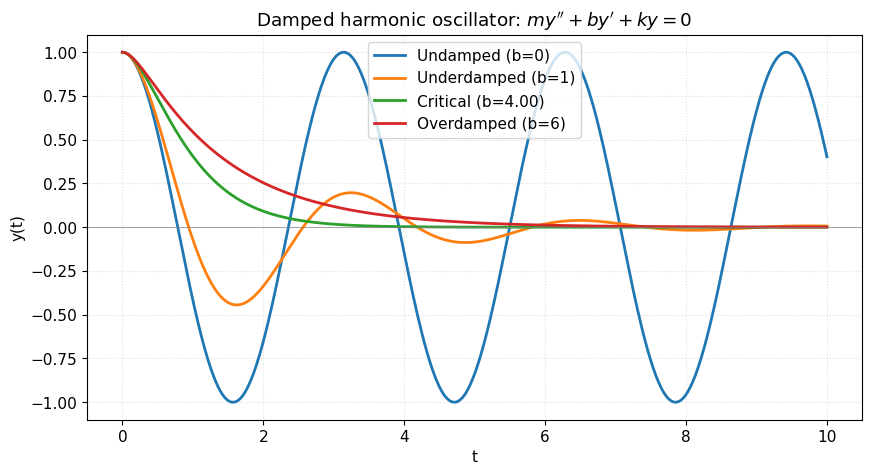

In [16]:
from scipy.integrate import odeint, solve_ivp

# Damped harmonic oscillator: m y'' + b y' + k y = 0
m, k_spring = 1.0, 4.0
damping_cases = {
    'Undamped (b=0)':       0.0,
    'Underdamped (b=1)':    1.0,
    f'Critical (b={2*np.sqrt(k_spring):.2f})': 2*np.sqrt(m*k_spring),
    'Overdamped (b=6)':     6.0,
}

def spring_ode(t, y, b_damp):
    return [y[1], (-b_damp * y[1] - k_spring * y[0]) / m]

t_span_ode = [0, 10]
t_eval = np.linspace(0, 10, 500)
y0_spring = [1.0, 0.0]

plt.figure(figsize=(10, 5))
for label, b in damping_cases.items():
    sol = solve_ivp(spring_ode, t_span_ode, y0_spring, args=(b,), t_eval=t_eval)
    plt.plot(sol.t, sol.y[0], lw=2, label=label)

plt.axhline(0, color='gray', ls='-', lw=0.5)
plt.xlabel('t'); plt.ylabel('y(t)')
plt.title('Damped harmonic oscillator: $my\'\'+ by\' + ky = 0$')
plt.legend()
plt.grid(True, ls=':', alpha=0.4)
plt.show()

#### Wronskian 与基本解组判别

下面这段代码用 **Wronskian** 检查两个候选解是否线性无关。在线性 ODE 里：只有线性无关的解，才能组成通解的「基」。

对二阶齐次线性 ODE

$$y'' - 3y' + 2y = 0$$

特征方程是

$$r^2 - 3r + 2 = 0$$

所以两个候选解是

$$y_1=e^x,\qquad y_2=e^{2x}$$

两个函数的 Wronskian 定义为

$$W(y_1,y_2)(x)=
\begin{vmatrix}
y_1(x) & y_2(x) \\
y_1'(x) & y_2'(x)
\end{vmatrix}$$

展开后就是

$$W(y_1,y_2)(x)=y_1(x)y_2'(x)-y_2(x)y_1'(x)$$

代入这里的两个解：

$$y_1=e^x,\qquad y_1'=e^x$$

$$y_2=e^{2x},\qquad y_2'=2e^{2x}$$

于是

$$W=e^x\cdot 2e^{2x}-e^{2x}\cdot e^x=e^{3x}$$

因为

$$e^{3x}\neq 0$$

所以 $y_1,y_2$ 线性无关，构成这个二阶齐次线性 ODE 的一组 fundamental solutions。通解就是

$$y=c_1e^x+c_2e^{2x}$$

直观理解：Wronskian 在问这两个函数是不是「同一个方向」的函数。如果 $y_2$ 只是 $y_1$ 的常数倍，例如 $y_2=3y_1$，那它们给不了两个真正不同的解方向，Wronskian 会等于 0。这里 $e^{2x}$ 不是 $e^x$ 的常数倍，所以 Wronskian 不为 0。

代码里的

$$W = y_1y_2' - y_2y_1'$$

对应这一行：

```python
W = y1 * y2p - y2 * y1p
```

后面画出 Wronskian 曲线，是为了可视化它始终不为 0。

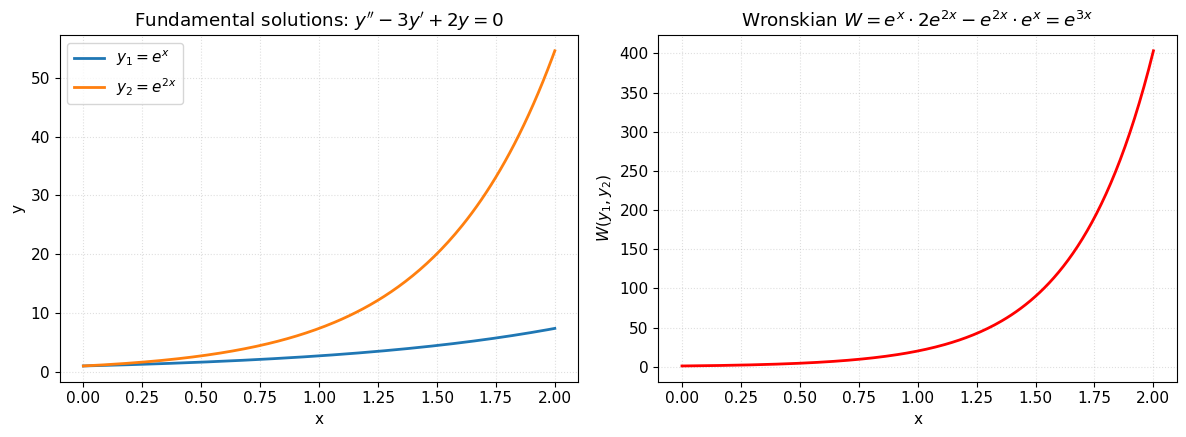

W(0) = 1.0000 (should be 1.0 = e^0)
W ≠ 0 everywhere ⇒ y1, y2 are linearly independent ⇒ form a fundamental set.


In [17]:
# Wronskian check and general solution for y'' - 3y' + 2y = 0
# Characteristic eqn: r^2 - 3r + 2 = 0  => r=1, r=2
# General solution: y = c1*e^x + c2*e^(2x)

x = np.linspace(0, 2, 200)
y1 = np.exp(x)
y2 = np.exp(2*x)
y1p = np.exp(x)
y2p = 2*np.exp(2*x)

W = y1 * y2p - y2 * y1p  # Wronskian

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Plot fundamental solutions
ax1.plot(x, y1, label='$y_1 = e^x$', lw=2)
ax1.plot(x, y2, label='$y_2 = e^{2x}$', lw=2)
ax1.set(xlabel='x', ylabel='y', title='Fundamental solutions: $y\'\'- 3y\' + 2y = 0$')
ax1.legend()
ax1.grid(True, ls=':', alpha=0.4)

# Wronskian
ax2.plot(x, W, 'r-', lw=2)
ax2.set(xlabel='x', ylabel='$W(y_1, y_2)$',
        title='Wronskian $W = e^x \\cdot 2e^{2x} - e^{2x} \\cdot e^x = e^{3x}$')
ax2.grid(True, ls=':', alpha=0.4)
plt.tight_layout()
plt.show()

print(f"W(0) = {W[0]:.4f} (should be 1.0 = e^0)")
print("W ≠ 0 everywhere ⇒ y1, y2 are linearly independent ⇒ form a fundamental set.")

---
## 第 9 章 — 微分方程组

### 一阶线性系统
$$\dot{x} = Ax + f(t), \quad x(t_0) = x_0$$

**齐次解**（$f=0$）：
- 若 $A$ 的 eigenvalue 为 $\lambda_i$，对应 eigenvector $v_i$：$x(t) = \sum c_i e^{\lambda_i t} v_i$
- 一般形式：$x(t) = e^{At} x_0$

### 相平面分类（二维系统）
对 $\dot{x} = Ax$（$A \in \mathbb{R}^{2\times 2}$），eigenvalue $\lambda_1, \lambda_2$：

| Eigenvalue 类型 | 相图 |
|---|---|
| $\lambda_1 < \lambda_2 < 0$（实） | 稳定结点（Stable Node） |
| $0 < \lambda_1 < \lambda_2$（实） | 不稳定结点（Unstable Node） |
| $\lambda_1 < 0 < \lambda_2$（实） | 鞍点（Saddle Point） |
| $\alpha \pm \beta i$，$\alpha < 0$ | 稳定螺旋（Stable Spiral） |
| $\alpha \pm \beta i$，$\alpha > 0$ | 不稳定螺旋（Unstable Spiral） |
| $\pm \beta i$（纯虚） | 中心（Center） |

### 非线性系统与线性化
$$\dot{x} = F(x)$$
在平衡点 $x^*$（$F(x^*)=0$）附近，**Jacobian** $J = \partial F/\partial x |_{x^*}$ 决定局部行为（Hartman–Grobman 定理，适用于双曲平衡点）。

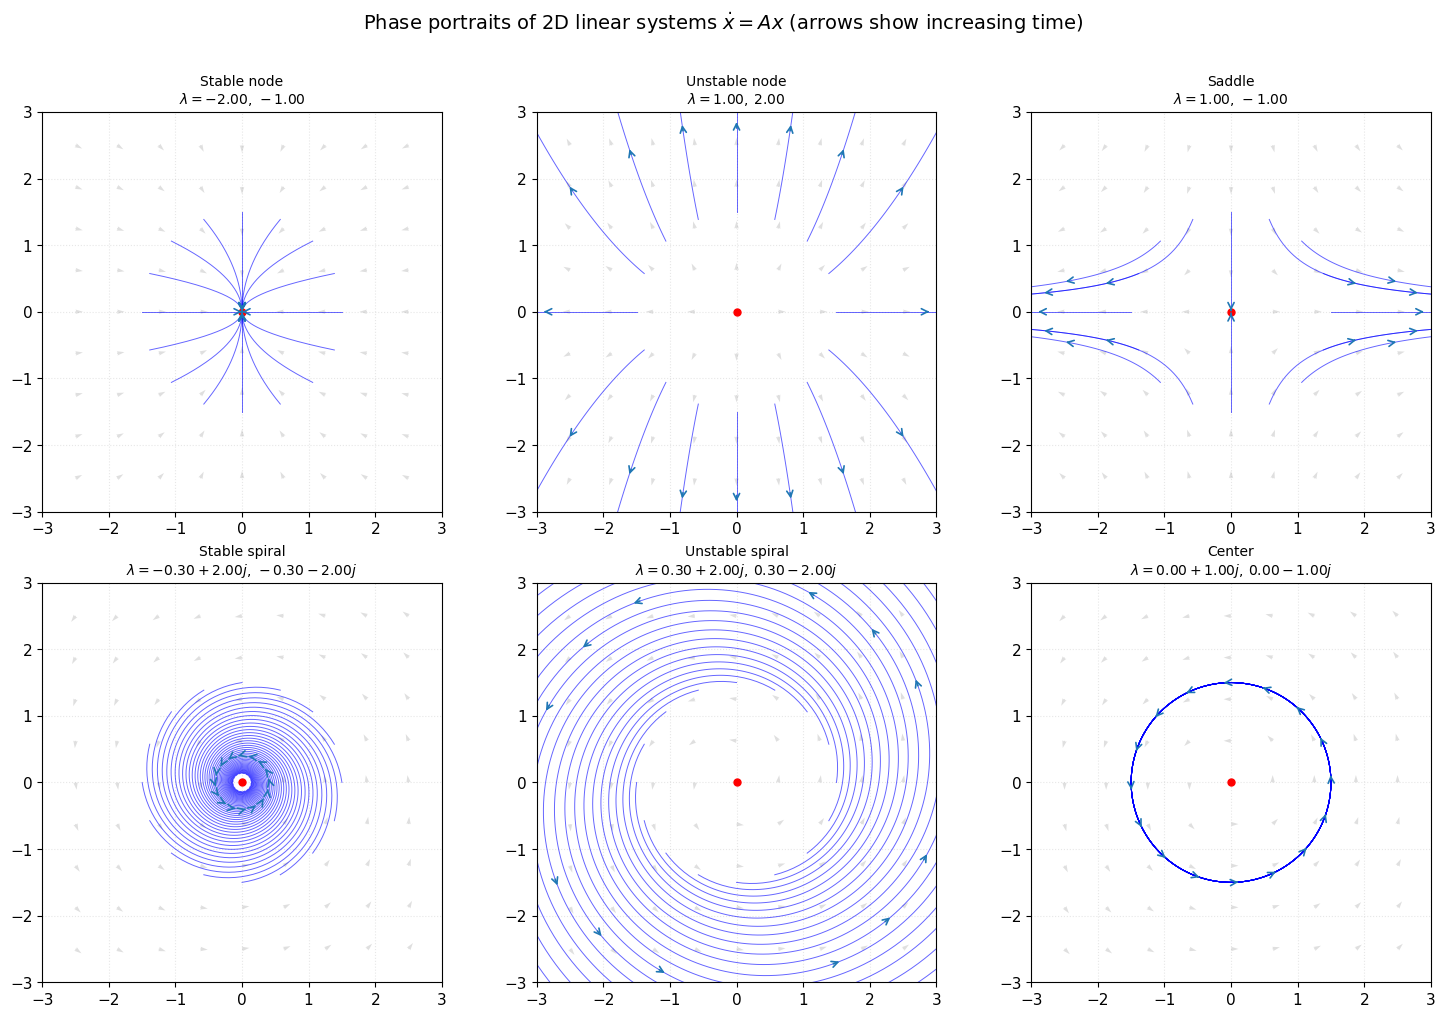

In [19]:
from scipy.linalg import expm
# Phase portraits for all 2D linear system types
systems = {
    'Stable node': np.array([[-2, 0], [0, -1]]),
    'Unstable node': np.array([[1, 0], [0, 2]]),
    'Saddle': np.array([[1, 0], [0, -1]]),
    'Stable spiral': np.array([[-0.3, -2], [2, -0.3]]),
    'Unstable spiral': np.array([[0.3, -2], [2, 0.3]]),
    'Center': np.array([[0, -1], [1, 0]]),
}

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
t_phase = np.linspace(0, 8, 500)

def add_flow_arrow(ax, traj, frac=0.55, color='tab:blue'):
    """Add one arrow along a trajectory, pointing toward increasing time."""
    if len(traj) < 3:
        return
    idx = int(frac * (len(traj) - 2))
    start = traj[idx]
    end = traj[idx + 1]
    ax.annotate(
        '',
        xy=end,
        xytext=start,
        arrowprops=dict(arrowstyle='->', color=color, lw=1.2, shrinkA=0, shrinkB=0),
        zorder=3,
    )

for ax, (name, A_mat) in zip(axes.flat, systems.items()):
    lam_vals = np.linalg.eigvals(A_mat)
    for angle in np.linspace(0, 2*np.pi, 16, endpoint=False):
        x0_ph = 1.5 * np.array([np.cos(angle), np.sin(angle)])
        traj = np.array([expm(A_mat * t) @ x0_ph for t in t_phase])
        mask = (np.abs(traj) < 5).all(axis=1)
        visible_traj = traj[mask]
        ax.plot(visible_traj[:, 0], visible_traj[:, 1], 'b-', lw=0.7, alpha=0.6)
        add_flow_arrow(ax, visible_traj)

    # Light vector-field arrows make inward/outward flow visible even between trajectories.
    grid = np.linspace(-2.5, 2.5, 9)
    X, Y = np.meshgrid(grid, grid)
    U = A_mat[0, 0] * X + A_mat[0, 1] * Y
    V = A_mat[1, 0] * X + A_mat[1, 1] * Y
    speed = np.hypot(U, V)
    U_norm = np.divide(U, speed, out=np.zeros_like(U), where=speed > 1e-12)
    V_norm = np.divide(V, speed, out=np.zeros_like(V), where=speed > 1e-12)
    ax.quiver(X, Y, U_norm, V_norm, color='gray', alpha=0.25, angles='xy', scale_units='xy', scale=9)

    ax.plot(0, 0, 'ro', ms=5)
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
    ax.set_aspect('equal')
    ax.set_title(f'{name}\n$\\lambda = {lam_vals[0]:.2f},\\, {lam_vals[1]:.2f}$', fontsize=10)
    ax.grid(True, ls=':', alpha=0.3)

plt.suptitle('Phase portraits of 2D linear systems $\dot{x} = Ax$ (arrows show increasing time)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


### Lotka-Volterra 捕食者-猎物模型：问题、建模与代码目标

前面的代码主要在画线性系统 $\dot{x}=Ax$ 的 phase portrait。下面这个例子换成一个**非线性系统**：捕食者-猎物（predator-prey）模型。它的目的不是再求一个矩阵指数，而是展示：

> 对非线性动力系统，我们仍然可以先建立 ODE 模型，然后看时间序列、phase plane、平衡点，以及在平衡点附近用 Jacobian 做线性化稳定性分析。

---

#### 1. 问题描述

假设有两个种群：

- $x(t)$：猎物数量，例如兔子；
- $y(t)$：捕食者数量，例如狐狸。

我们想描述它们随时间的相互影响：

1. 如果没有捕食者，猎物会自然繁殖；
2. 如果没有猎物，捕食者会因为缺少食物而死亡；
3. 猎物和捕食者相遇越多，猎物被吃掉越多；
4. 捕食越成功，捕食者获得食物后增长越快。

这类系统典型地不会单调收敛，而是会出现周期性的「猎物先增加 → 捕食者随后增加 → 猎物减少 → 捕食者减少 → 猎物恢复」的循环。

---

#### 2. 建模假设

设参数：

| 参数 | 含义 | 代码值 |
|---|---|---|
| $a$ | 猎物自然增长率 | $1.0$ |
| $b$ | 捕食造成猎物减少的强度 | $0.1$ |
| $c$ | 捕食者自然死亡率 | $1.5$ |
| $d$ | 捕食带来捕食者增长的效率 | $0.075$ |

对猎物 $x$：

$$\frac{dx}{dt} = ax - bxy$$

其中：

- $ax$：猎物自然增长；
- $bxy$：捕食造成猎物减少，和 $x,y$ 的乘积成正比，因为猎物和捕食者越多，相遇越频繁。

对捕食者 $y$：

$$\frac{dy}{dt} = -cy + dxy$$

其中：

- $-cy$：捕食者自然死亡；
- $dxy$：捕食者因为捕食获得食物而增长。

所以完整系统是

$$\dot{x}=ax-bxy,\qquad \dot{y}=-cy+dxy$$

这就是代码中的函数：

```python
def lotka_volterra(t, z):
    x, y = z
    return [a*x - b*x*y, -c*y + d*x*y]
```

---

#### 3. 数值实验与可视化解读

代码会从几个不同初始条件出发：

$$(x_0,y_0)=(10,5),(20,10),(30,5)$$

然后用 `solve_ivp` 数值求解 ODE。

左图是 **time series**：

- 横轴是时间 $t$；
- 纵轴是种群数量；
- 实线是猎物 $x(t)$；
- 虚线是捕食者 $y(t)$。

这张图用来观察两个种群怎样随时间振荡，以及谁先达到峰值。

右图是 **phase plane**：

- 横轴是猎物数量 $x$；
- 纵轴是捕食者数量 $y$；
- 每条曲线是状态点 $(x(t),y(t))$ 的轨迹。

这张图不直接显示时间，而是显示系统在状态空间里怎么绕平衡点运动。闭合轨道表示系统周期性循环。

---

#### 4. 平衡点与线性化

平衡点满足

$$\dot{x}=0,\qquad \dot{y}=0$$

对非零平衡点，有

$$x^*=\frac{c}{d},\qquad y^*=\frac{a}{b}$$

代入代码里的参数：

$$x^*=\frac{1.5}{0.075}=20,\qquad y^*=\frac{1.0}{0.1}=10$$

所以右图里的红色星号是平衡点 $(20,10)$。

因为系统是非线性的，不能直接用固定矩阵 $A$ 分析全局行为。但在平衡点附近，可以用 Jacobian 做局部线性化：

$$J =
\begin{pmatrix}
\frac{\partial}{\partial x}(ax-bxy) & \frac{\partial}{\partial y}(ax-bxy) \\
\frac{\partial}{\partial x}(-cy+dxy) & \frac{\partial}{\partial y}(-cy+dxy)
\end{pmatrix}
= \begin{pmatrix}
a-by & -bx \\
dy & -c+dx
\end{pmatrix}$$

在平衡点 $(20,10)$ 处，代码计算这个 $J$ 的 eigenvalues。如果 eigenvalues 是纯虚数，线性化系统表现为 **center**：绕着平衡点旋转，不向内收敛，也不向外发散。

这和 phase plane 里的闭合轨道一致。

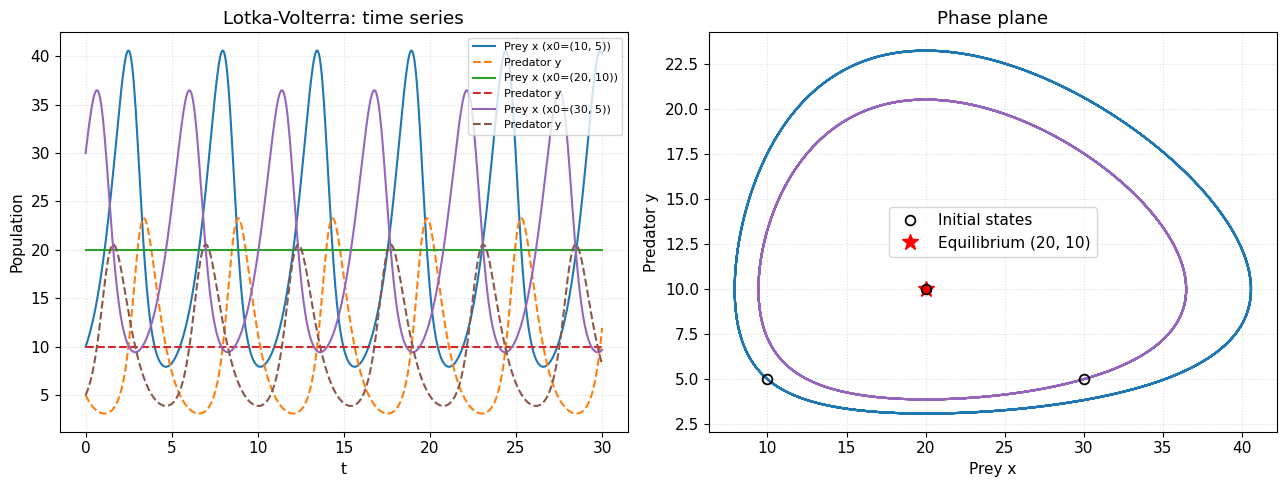

Equilibrium: (20.0, 10.0)
Jacobian at equilibrium:
[[ 0.   -2.  ]
 [ 0.75  0.  ]]
Eigenvalues: [0.+1.22474487j 0.-1.22474487j]
Purely imaginary ⇒ center (consistent with closed orbits).


In [23]:
# Nonlinear system: Lotka-Volterra (predator-prey)
# dx/dt = ax - bxy,  dy/dt = -cy + dxy
a, b, c, d = 1.0, 0.1, 1.5, 0.075

def lotka_volterra(t, z):
    x, y = z
    return [a*x - b*x*y, -c*y + d*x*y]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# 3 different initial conditions
for x0_lv in [(10, 5), (20, 10), (30, 5)]:
    # x0_lv means initial value of x0 in lotka_volterra model for example x0=10, y0=5
    sol = solve_ivp(lotka_volterra, [0, 30], x0_lv, max_step=0.05)
    ax1.plot(sol.t, sol.y[0], '-', lw=1.5, label=f'Prey x (x0={x0_lv})')
    ax1.plot(sol.t, sol.y[1], '--', lw=1.5, label=f'Predator y')
    # Phase plane: x-axis is prey x(t), y-axis is predator y(t).
    # This traces the state point (x(t), y(t)) as time evolves.
    ax2.plot(sol.y[0], sol.y[1], lw=1.5)
    # Mark the initial state (x(0), y(0)) for this trajectory.
    # The initial state (20, 10) overlaps with the equilibrium star, so use a hollow marker.
    ax2.plot(x0_lv[0], x0_lv[1], 'o', ms=7, mfc='none', mec='black', mew=1.3,
             label='Initial states' if x0_lv == (10, 5) else None, zorder=4)

# Equilibrium points
x_eq, y_eq = c/d, a/b
ax2.plot(x_eq, y_eq, 'r*', ms=12, label=f'Equilibrium ({x_eq:.0f}, {y_eq:.0f})')

ax1.set(xlabel='t', ylabel='Population', title='Lotka-Volterra: time series')
ax1.legend(fontsize=8)
ax1.grid(True, ls=':', alpha=0.4)

ax2.set(xlabel='Prey x', ylabel='Predator y', title='Phase plane')
ax2.legend()
ax2.grid(True, ls=':', alpha=0.4)
plt.tight_layout()
plt.show()

# Jacobian at equilibrium
J = np.array([[a - b*y_eq, -b*x_eq],
              [d*y_eq, -c + d*x_eq]])
print(f"Equilibrium: ({x_eq}, {y_eq})")
print(f"Jacobian at equilibrium:\n{J}")
print(f"Eigenvalues: {np.linalg.eigvals(J)}")
print("Purely imaginary ⇒ center (consistent with closed orbits).")

---
## 第 10 章 — Laplace 变换

### 定义
$$\mathcal{L}\{f(t)\}(s) = F(s) = \int_0^\infty e^{-st} f(t)\,dt$$

### 常用变换表

| $f(t)$ | $F(s)$ |
|--------|--------|
| $1$ | $1/s$ |
| $t^n$ | $n!/s^{n+1}$ |
| $e^{at}$ | $1/(s-a)$ |
| $\sin(\omega t)$ | $\omega/(s^2 + \omega^2)$ |
| $\cos(\omega t)$ | $s/(s^2 + \omega^2)$ |
| $e^{at}f(t)$ | $F(s-a)$（第一平移定理） |
| $u(t-a)f(t-a)$ | $e^{-as}F(s)$（第二平移定理） |

### 导数的变换
$$\mathcal{L}\{y'\} = sY(s) - y(0), \quad \mathcal{L}\{y''\} = s^2Y(s) - sy(0) - y'(0)$$

### 用 Laplace 变换解初值问题
1. 对方程两边取 $\mathcal{L}$。
2. 代数求解 $Y(s)$。
3. 逆变换：$y(t) = \mathcal{L}^{-1}\{Y(s)\}$（通常用部分分式展开）。

### 卷积（Convolution）
$$\mathcal{L}\{f * g\} = F(s)G(s), \quad (f*g)(t) = \int_0^t f(\tau)g(t-\tau)\,d\tau$$

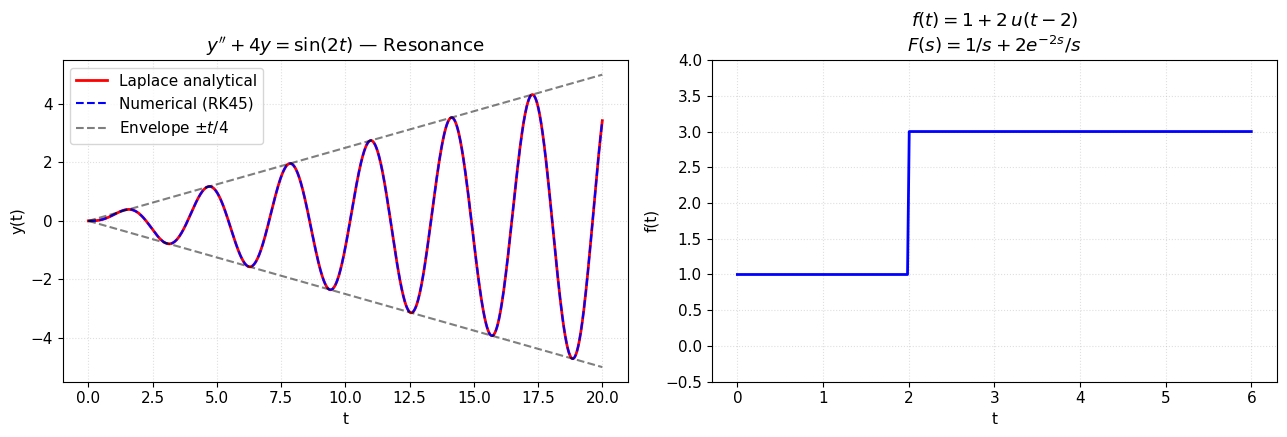

In [34]:
# Example: solve y'' + 4y = sin(2t), y(0)=0, y'(0)=0 via Laplace
# Analytical: Y(s) = 2/((s^2+4)^2)  =>  y(t) = (sin(2t) - 2t cos(2t))/8  (resonance!)

t = np.linspace(0, 20, 1000)
y_laplace = (np.sin(2*t) - 2*t*np.cos(2*t)) / 8

# Verify numerically
sol = solve_ivp(lambda t, y: [y[1], np.sin(2*t) - 4*y[0]], [0, 20], [0, 0],
                t_eval=t, max_step=0.01)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
ax1.plot(t, y_laplace, 'r-', lw=2, label='Laplace analytical')
ax1.plot(sol.t, sol.y[0], 'b--', lw=1.5, label='Numerical (RK45)')
ax1.set(xlabel='t', ylabel='y(t)', title="$y'' + 4y = \\sin(2t)$ — Resonance")
ax1.legend()
ax1.grid(True, ls=':', alpha=0.4)

# Envelope
envelope = t / 4
ax1.plot(t, envelope, 'k--', alpha=0.5, label='Envelope $\\pm t/4$')
ax1.plot(t, -envelope, 'k--', alpha=0.5)
ax1.legend()

# Unit step function and Laplace application
# f(t) = 1 for t<2, 3 for t>=2  =>  f = 1 + 2u(t-2)
t2 = np.linspace(0, 6, 300)
f_step = np.where(t2 < 2, 1, 3)

ax2.plot(t2, f_step, 'b-', lw=2)
ax2.set(xlabel='t', ylabel='f(t)',
        title='$f(t) = 1 + 2\\,u(t-2)$\n$F(s) = 1/s + 2e^{-2s}/s$')
ax2.grid(True, ls=':', alpha=0.4)
ax2.set_ylim(-0.5, 4)
plt.tight_layout()
plt.show()

---
## 第 11 章 — 级数解法

### 导读：级数解法的适用场景与基本思想

前面介绍的 ODE 解法主要适用于结构较简单的情形：

- 常系数齐次方程：令 $y=e^{rx}$，将微分方程转化为特征方程；
- 非齐次方程：在合适条件下使用待定系数法或参数变分法；
- 一阶线性系统：通过矩阵指数 $e^{At}$ 表示解。

然而，许多重要的微分方程具有变系数形式，例如

$$y'' - xy = 0$$

以及

$$(1-x^2)y'' - 2xy' + N(N+1)y = 0$$

这类方程通常无法表示为初等函数的闭式解，也不能直接通过常系数特征方程求解。此时可以采用级数表示：将未知函数表示为幂级数，并由微分方程确定其系数。

基本假设为

$$y(x)=a_0+a_1x+a_2x^2+a_3x^3+\cdots = \sum_{n=0}^{\infty} a_n x^n$$

具体步骤如下：

1. 对幂级数逐项求导，得到 $y'$ 和 $y''$；
2. 将 $y,y',y''$ 代入原微分方程；
3. 按 $1,x,x^2,x^3,\ldots$ 的幂次整理；
4. 由于方程需对所有 $x$ 成立，各幂次对应的系数必须分别为 0；
5. 由系数匹配得到 $a_n$ 的递推关系。

因此，级数解法的核心是：

> 将求解未知函数 $y(x)$ 的问题，转化为求解系数序列 $a_0,a_1,a_2,\ldots$ 的问题。

其中 $a_0$ 和 $a_1$ 通常由初始条件决定；更高阶系数 $a_2,a_3,\ldots$ 则由微分方程给出的递推关系确定。

Legendre 多项式、Bessel 函数、Airy 函数等特殊函数，均可理解为某些重要微分方程的级数解。

---

### 在常点处的幂级数解（Power Series Solution）
对 $y'' + p(x)y' + q(x)y = 0$，若 $x_0$ 是**常点（Ordinary Point）**（即 $p$ 和 $q$ 在 $x_0$ 处解析），则解可以展开为幂级数：
$$y(x) = \sum_{n=0}^\infty a_n (x - x_0)^n$$

代入 ODE，匹配系数，得到 $a_n$ 的**递推关系**。

### Legendre 方程
$$(1-x^2)y'' - 2xy' + N(N+1)y = 0$$
当 $N$ 为非负整数时，一个解是 $N$ 次 **Legendre 多项式** $P_N(x)$。

### Frobenius 方法（正则奇点）
若 $x_0$ 是**正则奇点（Regular Singular Point）**，尝试 $y = \sum a_n x^{n+r}$，通过**指标方程（Indicial Equation）**确定 $r$。

### Bessel 方程
$$x^2 y'' + xy' + (x^2 - p^2)y = 0$$
解为 **Bessel 函数** $J_p(x)$（第一类，$p$ 阶）。

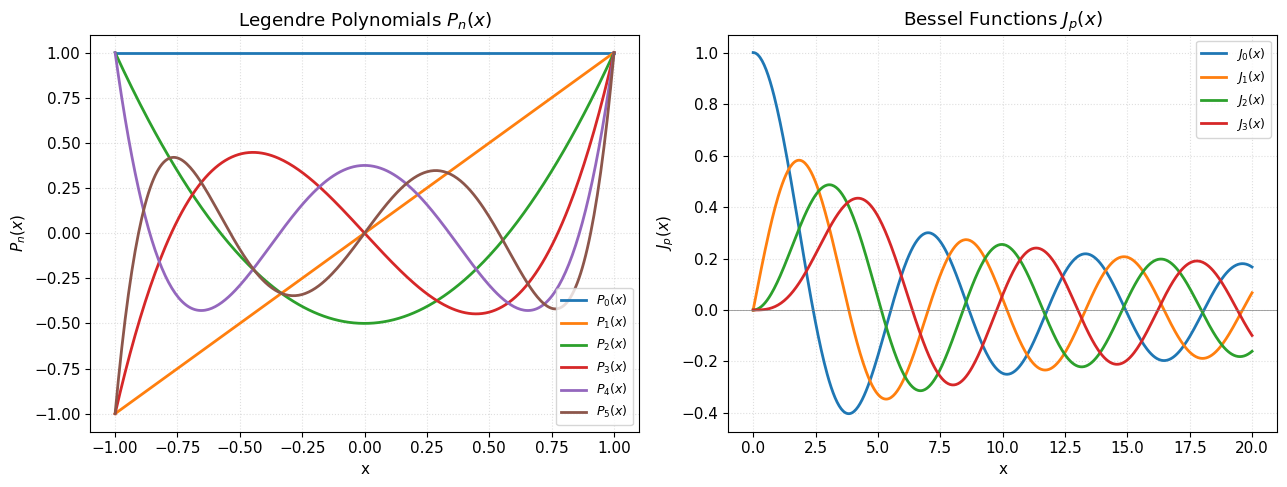

In [35]:
# Legendre polynomials via recurrence and SciPy
from scipy.special import legendre, jv

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

x = np.linspace(-1, 1, 300)
for n in range(6):
    Pn = legendre(n)
    ax1.plot(x, Pn(x), lw=2, label=f'$P_{n}(x)$')

ax1.set(xlabel='x', ylabel='$P_n(x)$', title='Legendre Polynomials $P_n(x)$')
ax1.legend(fontsize=9)
ax1.grid(True, ls=':', alpha=0.4)

# Bessel functions
x_b = np.linspace(0, 20, 500)
for p in [0, 1, 2, 3]:
    ax2.plot(x_b, jv(p, x_b), lw=2, label=f'$J_{p}(x)$')

ax2.set(xlabel='x', ylabel='$J_p(x)$', title='Bessel Functions $J_p(x)$')
ax2.legend(fontsize=9)
ax2.axhline(0, color='gray', lw=0.5)
ax2.grid(True, ls=':', alpha=0.4)
plt.tight_layout()
plt.show()

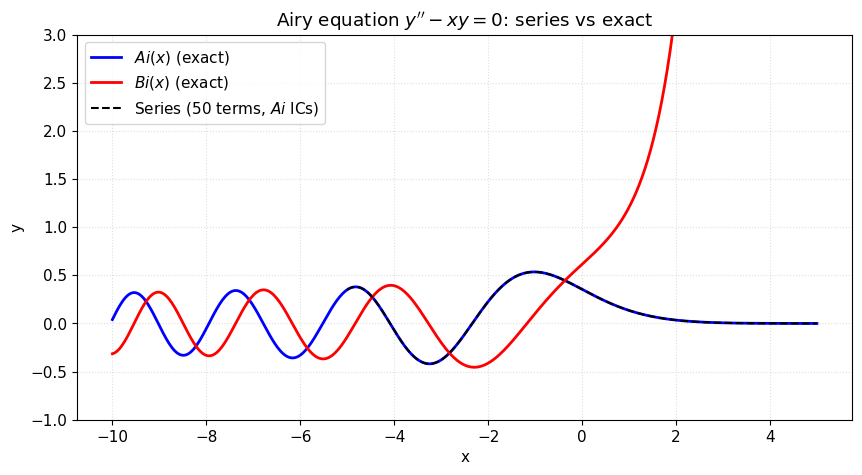

In [36]:
# Series solution: Airy equation y'' - xy = 0 (ordinary point at x=0)
# Recurrence: a_{n+2} = a_{n-1} / ((n+1)(n+2))

def airy_series(x, N_terms=30, y0=1.0, y1=0.0):
    """Compute series solution y = sum a_n x^n for Airy equation."""
    a = np.zeros(N_terms)
    a[0] = y0
    a[1] = y1
    for n in range(0, N_terms - 3):
        a[n + 3] = a[n] / ((n + 2) * (n + 3))
    y = sum(a[n] * x**n for n in range(N_terms))
    return y

# Compare with scipy's Airy function
from scipy.special import airy

x = np.linspace(-10, 5, 500)
Ai, Aip, Bi, Bip = airy(x)

x_series = np.linspace(-5, 5, 500)
y_series = airy_series(x_series, N_terms=50, y0=airy(0)[0], y1=airy(0)[1])

plt.figure(figsize=(10, 5))
plt.plot(x, Ai, 'b-', lw=2, label='$Ai(x)$ (exact)')
plt.plot(x, Bi, 'r-', lw=2, label='$Bi(x)$ (exact)')
plt.plot(x_series, y_series, 'k--', lw=1.5, label='Series (50 terms, $Ai$ ICs)')
plt.ylim(-1, 3)
plt.xlabel('x'); plt.ylabel('y')
plt.title("Airy equation $y'' - xy = 0$: series vs exact")
plt.legend()
plt.grid(True, ls=':', alpha=0.4)
plt.show()

---
## 解法总结

| ODE 类型 | 方法 |
|----------|------|
| $y' = g(x)h(y)$ | 分离变量法 |
| $y' + p(x)y = q(x)$ | 积分因子 $e^{\int p\,dx}$ |
| $M\,dx + N\,dy = 0$（$M_y = N_x$） | 恰当方程（Exact Equation） |
| 常系数齐次 | 特征方程 |
| 非齐次 | 待定系数法 / 参数变分法 |
| $\dot{x} = Ax$ | Matrix Exponential $e^{At}$ |
| 任意初值问题 | Laplace 变换 |
| 变系数（常点附近） | 幂级数解法 |
| 变系数（正则奇点） | Frobenius 方法 |
| 数值方法 | Euler / Heun / RK4 |

---
## ML 视角总结：训练收敛、稳定性与量化

线性 ODE + 特征值这一整套语言，是分析“训练动力学 / 优化收敛 / RNN 稳定性 / 扩散过程”的数学基础。

> 神经网络训练的局部行为 $\approx$ 线性 ODE，权重的演化稳定性 = 这个 ODE 的特征值在哪里；齐次解 = "自然收敛部分"，特解 = "对噪声/外力的响应"。

### 梯度下降是离散的 ODE

```math
\dot\theta = -\nabla L(\theta)
```

在最优点 $\theta^*$ 附近做泰勒展开 $L(\theta)\approx L(\theta^*)+\tfrac12(\theta-\theta^*)^T H(\theta-\theta^*)$，于是 $\nabla L(\theta)\approx H(\theta-\theta^*)$。令 $z=\theta-\theta^*$，得到一个**齐次**线性 ODE 系统：
$$\dot z = -Hz, \qquad F=0$$
这就是齐次方程出现的地方——“在最优点附近，没有外力，系统按自己的内在动力学（Hessian 决定）演化”。

### Hessian 特征值与训练稳定性

按 Matrix Exponential 一节的结论 $z(t)=e^{-Ht}z_0$。如果 $H$ 正定，特征值 $\lambda_i>0$，那 $-H$ 的特征值 $-\lambda_i<0$，每个方向：
$$z_i(t) = e^{-\lambda_i t} z_{i,0} \to 0$$
所有方向衰减 → 训练收敛。但是：
- $\lambda_i$ 大 → 衰减快（陡峭方向）；
- $\lambda_i$ 小 → 衰减慢（平坦方向）。

### 离散梯度下降的稳定性与 Condition Number

把连续 ODE $\dot z = -Hz$ 用最简单的显式 Euler（步长 $\eta$）离散：
$$z_{k+1} = z_k + \eta\,\dot z_k = z_k - \eta H z_k = (I - \eta H)\, z_k$$
这就是 ODE 视角下的离散梯度下降迭代矩阵 $I - \eta H$。在 $H$ 的特征基下分解，$z = \sum_i z^{(i)} v_i$，每个分量独立演化：
$$z^{(i)}_{k+1} = (1 - \eta\lambda_i)\, z^{(i)}_k$$

**稳定性约束**：要每个方向都不发散，需要 $|1-\eta\lambda_i|<1$ 对所有 $i$ 成立，最严的是最大特征值：
$$\eta < \frac{2}{\lambda_{\max}(H)}$$
超过这个上限，最大特征值方向 $|1-\eta\lambda_{\max}|>1$，loss 变 NaN。这正是齐次线性 ODE “特征值符号决定稳定性” 的离散对应物。

**收敛速度**：取典型选择 $\eta = 1/\lambda_{\max}$，最慢的方向（小 $\lambda_{\min}$）每步衰减系数为
$$|1 - \eta\lambda_{\min}| = 1 - \frac{1}{\kappa},\qquad \kappa = \frac{\lambda_{\max}}{\lambda_{\min}}$$
要把误差降到 $\varepsilon$，需要
$$k \approx \kappa\,\log\frac{1}{\varepsilon}$$
**步数和 condition number $\kappa$ 成正比**。$\kappa$ 大 10 倍，训练慢 10 倍。

### 几何直觉：椭圆等高线与 Zig-Zag

二维椭圆的标准形式是

$$\frac{z_1^2}{a_1^2}+\frac{z_2^2}{a_2^2}=1$$

其中 $a_1,a_2$ 是两条主轴方向上的半轴长度。

对二次损失，在 Hessian 特征基下有

$$f(z)=\frac12 z^T\Lambda z=\frac12(\lambda_1z_1^2+\lambda_2z_2^2)$$

等高线 $f(z)=c$ 满足

$$\lambda_1z_1^2+\lambda_2z_2^2=2c$$

整理成椭圆标准形式：

$$\frac{z_1^2}{2c/\lambda_1}+\frac{z_2^2}{2c/\lambda_2}=1$$

因此第 $i$ 个特征方向上的半轴长度是

$$a_i=\sqrt{\frac{2c}{\lambda_i}}$$

由此得到：

- $\lambda$ 大 → $a$ 小 → 这是椭圆的**短半轴**方向（陡）；
- $\lambda$ 小 → $a$ 大 → 这是椭圆的**长半轴**方向（平）；
- 长短轴比 $= \sqrt{\kappa}$，所以 $\kappa$ 大就是“长条山谷”。

**GD 的方向错配：**
- “**梯度大**”的方向 = 短轴方向（陡），但这个方向**本来就不需要走多远**；
- “**真正需要走远**”的方向 = 长轴方向（平），但梯度很小，每步走得少。

结果是 GD 沿短轴方向反复横跳（zig-zag），沿长轴方向几乎不动——大部分能量浪费在“不该走那么多”的方向上。

```text
       ●  ←── 极小点（要去的远方在长轴方向）
     ↗ ↘
   ↗     ↘
 ●         ●         GD 在短轴方向反复横跳
   ↘     ↗
     ↘ ↗
       ●
```

### 优化器视角：降低等效 $\kappa$

前面几节得到两个结论：

1. 大特征值方向曲率高，限制学习率上限；
2. 小特征值方向曲率低，在稳定学习率下收敛最慢。

因此，训练困难并不只是因为某一个方向“太陡”或“太平”，而是因为不同方向的曲率差异太大。这个差异由 condition number 描述：

$$\kappa=\frac{\lambda_{\max}}{\lambda_{\min}}$$

当 $\kappa$ 很大时，损失地形像长条山谷：为了不在陡方向发散，学习率必须很小；但这个学习率又会导致平方向推进缓慢。

从这个角度看，许多优化器可以理解为在改变参数空间中的“有效几何”：

- momentum 通过历史梯度累积，缓解短轴振荡并加速长轴移动；
- adaptive methods 通过 per-coordinate 缩放，让不同坐标方向的有效步长不同；
- second-order / preconditioning 方法显式或近似地使用曲率信息，把长条山谷变得更接近圆形碗。

因此，“降低等效 $\kappa$”不是指真的改变原始 Hessian 的特征值，而是指在优化器诱导的更新规则下，让各方向的收敛速度更均衡。

| 方法 | 核心更新公式 | 思路 | 等效 $\kappa$ |
|------|------|------|--------------|
| **GD** | $\theta_{k+1} = \theta_k - \eta\,\nabla L(\theta_k)$ | 单一 $\eta$ 应付所有方向，被 $\lambda_{\max}$ 卡死 | $\kappa$ |
| **Polyak Momentum (heavy-ball)** | $v_{k+1} = \beta v_k + \nabla L(\theta_k)$<br>$\theta_{k+1} = \theta_k - \eta\,v_{k+1}$ | 累积"惯性"：长轴方向同号叠加加速，短轴方向反号相消减振荡 | $\sqrt\kappa$（二次问题最优） |
| **Nesterov Accelerated Gradient** | $\tilde\theta_k = \theta_k + \beta(\theta_k - \theta_{k-1})$<br>$\theta_{k+1} = \tilde\theta_k - \eta\,\nabla L(\tilde\theta_k)$ | 在"前瞻点"算梯度后再回拉，对凸函数最优 | $\sqrt\kappa$，凸下 $O(1/k^2)$ |
| **Adagrad** | $G_k = \sum_{i\le k} g_i \odot g_i$<br>$\theta_{k+1} = \theta_k - \eta\,g_k / \sqrt{G_k + \varepsilon}$ | 用历史梯度平方累计做 per-coordinate 缩放，第一篇自适应方法 | 对角近似 $\kappa$ 拉平 |
| **RMSprop** | $G_k = \rho G_{k-1} + (1-\rho)\,g_k\odot g_k$<br>$\theta_{k+1} = \theta_k - \eta\,g_k/\sqrt{G_k+\varepsilon}$ | Adagrad 的指数滑动平均版，避免学习率单调归零 | 同上 |
| **Adam** | $m_k = \beta_1 m_{k-1} + (1-\beta_1)\,g_k$<br>$v_k = \beta_2 v_{k-1} + (1-\beta_2)\,g_k\odot g_k$<br>$\theta_{k+1} = \theta_k - \eta\,\hat m_k / (\sqrt{\hat v_k} + \varepsilon)$ | 动量 + RMSprop 二阶矩自适应预处理（带 bias correction $\hat m, \hat v$） | 同上，对深度网络效果更稳 |
| **Newton** | $\theta_{k+1} = \theta_k - H^{-1}(\theta_k)\,\nabla L(\theta_k)$ | 用真实 Hessian 逆把所有方向曲率拉平到 $1$ | $1$（局部一步收敛） |
| **L-BFGS / K-FAC / Shampoo** | $\theta_{k+1} = \theta_k - \eta\,\hat H_k^{-1}\,\nabla L$ | 用结构化方式近似 $H^{-1}$（low-rank、Kronecker 积等） | 介于 $\sqrt\kappa$ 和 $1$ 之间 |
| **Preconditioning** | $\theta' = P^{1/2}\theta$ 后做 GD | 显式坐标变换让损失变成圆碗 | 由 $P$ 控制 |

> 记号：$g_k = \nabla L(\theta_k)$，$\odot$ 是逐元素乘法，$\hat m_k = m_k/(1-\beta_1^k)$、$\hat v_k = v_k/(1-\beta_2^k)$ 是 Adam 的 bias correction。

**ML优化思路：**
> ML 优化器开发演进 = 想办法把"等效 $\kappa$"做小 = 把"长条山谷"压成"圆形碗"。

**主要文献支撑这条逻辑：**

- **Boyd & Vandenberghe, *Convex Optimization* (2004), §9.3** — GD 收敛率与 condition number 的关系（教材标准证明 $f(x_k)-p^\star \le c^k(f(x_0)-p^\star)$，$c=1-1/\kappa$）。
- **Polyak, "Some methods of speeding up the convergence of iteration methods" (USSR Comp. Math, 1964)** — heavy-ball / momentum 原始论文，证明二次函数上加速到 $\sqrt\kappa$。
- **Nesterov, "A method of solving a convex programming problem with convergence rate $O(1/k^2)$" (Soviet Math. Dokl., 1983)** — Nesterov 加速法，凸一阶方法的最优 lower bound。
- **Su, Boyd, Candès, "A Differential Equation for Modeling Nesterov's Accelerated Gradient Method" (NIPS 2014)** — 用 ODE 解释加速本质上是"减小等效 condition number"。
- **Duchi, Hazan, Singer, "Adaptive Subgradient Methods for Online Learning and Stochastic Optimization" (Adagrad, JMLR 2011)** — 第一篇 per-coordinate preconditioning。
- **Kingma & Ba, "Adam: A Method for Stochastic Optimization" (ICLR 2015)** — Adam 论文 motivation 章节直接说"can be viewed as preconditioning"。
- **Martens & Grosse, "Optimizing Neural Networks with Kronecker-factored Approximate Curvature" (K-FAC, ICML 2015)** — 神经网络近似二阶方法。
- **Bottou, Curtis, Nocedal, "Optimization Methods for Large-Scale Machine Learning" (SIAM Review, 2018)** — ML 优化 survey，把 second-order / preconditioning / variance reduction 三类改进框定为"克服 $\kappa$ 大的问题"。
- **Goh, "Why Momentum Really Works" (Distill, 2017)** — 用动画把"GD zig-zag → momentum 把 $\kappa$ 减到 $\sqrt\kappa$"讲得最直观。

### SGD 噪声的非齐次项解读

如果有 SGD 噪声，迭代变成
$$z_{k+1} = (I - \eta H)\,z_k + \eta\,\xi_k$$
这就是**非齐次**线性差分方程：齐次部分 $(I-\eta H)z_k$ 决定收敛，非齐次部分 $\eta\xi_k$ 决定"在最优点附近抖动多大"。所以即便齐次稳定，最终损失也不会归零，而是停在一个**噪声决定的平衡值**上——这正是 SGD 的"实际最低 loss"和 GD 不同的原因。

### RNN 长程依赖与梯度稳定性

RNN 隐藏状态演化 $h_{t+1}=W h_t + (\text{input})$，信号传播部分（去掉输入）就是齐次：
$$h_{t+1} = W h_t$$
$W$ 的特征值决定信号能不能跨时间步存活：
- $|\lambda_i|<1$：梯度消失；
- $|\lambda_i|>1$：梯度爆炸；
- $|\lambda_i|=1$：信号保持（LSTM / unitary RNN 想做到这一点）。

“gradient vanishing / exploding”本质上都是**齐次线性系统的稳定性问题**。

### 阻尼振子与训练动力学

Momentum 的连续时间形式可以看作一个带惯性和阻尼的二阶系统。普通 gradient flow 是一阶 ODE：

$$
\dot\theta = -\nabla L(\theta)
$$

它只描述当前位置 $\theta$ 如何变化，没有显式的速度变量。Momentum 引入了速度 / 动量变量，因此连续化后会出现加速度项 $\ddot\theta$。

以 heavy-ball momentum 为例，常见离散更新可以写成

$$
\theta_{k+1}=\theta_k+\beta(\theta_k-\theta_{k-1})-\eta\nabla L(\theta_k)
$$

把它移项：

$$
\theta_{k+1}-2\theta_k+\theta_{k-1}=-(1-\beta)(\theta_k-\theta_{k-1})-\eta\nabla L(\theta_k)
$$

设连续时间步长为 $h$，令 $\theta_k\approx \theta(t)$。二阶差分近似加速度：

$$
\theta_{k+1}-2\theta_k+\theta_{k-1}\approx h^2\ddot\theta(t)
$$

一阶差分近似速度：

$$
\theta_k-\theta_{k-1}\approx h\dot\theta(t)
$$

代入上式并除以 $h^2$，得到

$$
\ddot\theta(t)+\frac{1-\beta}{h}\dot\theta(t)+\frac{\eta}{h^2}\nabla L(\theta(t))=0
$$

这就是 momentum 的连续时间近似。将系数重新记为质量 $m$ 和阻尼 $b$，即可写成典型形式

$$
m\ddot\theta + b\dot\theta + \nabla L(\theta)=0
$$

其中 $1-\beta$ 控制阻尼大小，$\eta$ 与时间尺度共同决定梯度力的强度。$\beta$ 越接近 1，阻尼越小，惯性越强；$\beta$ 较小，则阻尼更强。

这与弹簧-质量-阻尼系统

$$
my'' + by' + ky = 0
$$

具有相同结构。对应关系为：

| 机械系统 | 优化系统 |
|---|---|
| 位置 $y$ | 参数 $\theta$ |
| 速度 $y'$ | 参数更新速度 $\dot\theta$ |
| 加速度 $y''$ | 动量变化 / 加速度 $\ddot\theta$ |
| 弹簧力 $ky$ | 梯度力 $\nabla L(\theta)$ |
| 阻尼项 $by'$ | friction / damping，抑制振荡 |
| 质量 $m$ | inertia，决定惯性大小 |

因此可以把带 momentum 的训练过程理解为：参数像一个带质量的小球，在 loss surface 上受到梯度力牵引，同时受到阻尼摩擦。

在最优点 $\theta^*$ 附近，令

$$
z = \theta - \theta^*
$$

对梯度做一阶近似：

$$
\nabla L(\theta) \approx H(\theta-\theta^*) = Hz
$$

又因为 $\theta^*$ 是常数，故

$$
\dot\theta=\dot z,\qquad \ddot\theta=\ddot z
$$

代入 momentum 的连续时间方程，得到局部线性化系统：

$$
m\ddot z + b\dot z + Hz = 0
$$

再切到 Hessian 的特征基，每个方向独立满足

$$
m\ddot z_i + b\dot z_i + \lambda_i z_i = 0
$$

这与单自由度弹簧系统完全同型，只是弹簧刚度 $k$ 被 Hessian 特征值 $\lambda_i$ 替代。由此得到训练动力学的解释：

- 大 $\lambda_i$：曲率高，类似很硬的弹簧，容易产生快速振荡；
- 小 $\lambda_i$：曲率低，类似很软的弹簧，恢复速度慢；
- 阻尼 $b$ 太小：欠阻尼，收敛时振荡明显；
- 阻尼 $b$ 太大：过阻尼，振荡少但移动缓慢；
- 合适的阻尼：接近临界阻尼，尽可能快地非振荡收敛。

因此，momentum 参数调节可以理解为在不同曲率方向上选择合适的惯性与阻尼：既避免陡方向反复震荡，又让平方向获得足够推进。

### AdamW 训练动力学：自适应步长与解耦权重衰减

AdamW 在工程上几乎是当下大模型训练的默认优化器。它本质上是 **动量 + 对角 preconditioner + 解耦权重衰减** 的组合。把它放回本章 ODE / 二次型 / Condition Number 的语言里，可以看清它做了什么、以及为什么比 SGD 更鲁棒。

#### 更新规则

记 $g_t=\nabla L(\theta_t)$ 为当前 batch 的梯度，$\beta_1,\beta_2\in(0,1)$，$\eta$ 为学习率，$\lambda$ 为权重衰减系数：

$$\begin{aligned}
m_t &= \beta_1\,m_{t-1} + (1-\beta_1)\,g_t \\
v_t &= \beta_2\,v_{t-1} + (1-\beta_2)\,g_t\odot g_t \\
\hat m_t &= m_t/(1-\beta_1^t),\qquad \hat v_t = v_t/(1-\beta_2^t) \\
\theta_{t+1} &= \theta_t - \eta\Big(\frac{\hat m_t}{\sqrt{\hat v_t}+\varepsilon} + \lambda\,\theta_t\Big)
\end{aligned}$$

它做的事情可以拆成四件：

- **动量项 $m_t$**（一阶矩 / *first moment*）：梯度 $g_t$ 的指数移动平均（EMA），起到 Polyak heavy-ball / 低通滤波的作用。这里的"动量"是从 Polyak heavy-ball 借来的命名习惯——把参数更新方向当作受过去梯度推动的"速度"，**和梯度同量纲**；不要按物理上 $p=mv$ 的"质量×速度"理解。
- **二阶项 $v_t$**（二阶矩 / *second raw moment estimate*）：梯度平方 $g_t^2$ 的 EMA，估计每个坐标上的 $\overline{g^2}$，给出"近期梯度能量"。**$v$ 只是符号，不是物理速度，也不是动量**——它和动量项 $m_t$ 是两套独立的统计量。
- **自适应步长 $1/\sqrt{\hat v_t}$**：按坐标缩放，使大梯度方向走小步、小梯度方向走大步；
- **解耦权重衰减 $\lambda\theta_t$**：直接对参数做收缩，不进入 $g_t$，不被 $\sqrt{\hat v_t}$ 缩放。

**具体例子：1D 二次损失上跑 4 步**

取最简的 1D 凸问题 $L(\theta)=\tfrac12\theta^2$，于是 $g_t=\theta_t$。超参用工程常用值：

$$\eta=0.1,\quad \beta_1=0.9,\quad \beta_2=0.999,\quad \lambda=0.01,\quad \varepsilon=10^{-8},\quad \theta_0=1.0$$

逐步代入公式（$m_0=v_0=0$）：

| $t$ | $\theta_t$ | $g_t$ | $m_t$ | $v_t$ | $\hat m_t$ | $\hat v_t$ | $\hat m_t/\sqrt{\hat v_t}$ | $\lambda\theta_t$ | $\Delta\theta_t$ | $\theta_{t+1}$ |
|---|---|---|---|---|---|---|---|---|---|---|
| 1 | 1.0000 | 1.0000 | 0.1000 | 0.001000 | 1.0000 | 1.0000 | 1.0000 | 0.0100 | 0.1010 | 0.8990 |
| 2 | 0.8990 | 0.8990 | 0.1799 | 0.001807 | 0.9468 | 0.9041 | 0.9958 | 0.0090 | 0.1005 | 0.7985 |
| 3 | 0.7985 | 0.7985 | 0.2418 | 0.002443 | 0.8921 | 0.8152 | 0.9881 | 0.0080 | 0.0996 | 0.6989 |
| 4 | 0.6989 | 0.6989 | 0.2875 | 0.002929 | 0.8359 | 0.7334 | 0.9761 | 0.0070 | 0.0983 | 0.6006 |

第一步 $t=1$ 是一切玄机的来源：未修正的 $m_1=0.1$ 偏小，$v_1=0.001$ 也偏小，但 bias correction 把它们都放大成 $\hat m_1=1.0,\hat v_1=1.0$。然后 $\hat m_1/\sqrt{\hat v_1}=1.0$，再乘 $\eta$ 得到 $\eta\cdot 1.0 = 0.1$ 的"标准步"。如果不做 bias correction，第一步会是 $\eta\cdot m_1/\sqrt{v_1}=0.1\cdot 0.1/\sqrt{0.001}\approx 0.32$，比合理步长大 **3 倍**，前几步就会失稳。

第 2、3、4 步可以观察到 $\hat m_t/\sqrt{\hat v_t}\approx 1$、$\Delta\theta_t\approx \eta=0.1$，每步几乎是一个**固定大小的步**，与 $|g_t|$ 大小基本无关——这就是后面 「自适应步长与稳定性边界」 要解释的 *sign-SGD-like* 行为。对照一下纯 GD：同样 $\eta=0.1$ 时 $\theta_{t+1}=(1-\eta)\theta_t$，序列是 $1.0\to 0.9\to 0.81\to 0.729\to 0.6561$（乘性衰减、每步随梯度变小而变小）；而 AdamW 序列是 $1.0\to 0.899\to 0.7985\to 0.6989\to 0.6006$（近乎加性衰减、每步基本恒定）。

最后一列里 $\lambda\theta_t$ 是单独的 weight decay 通道，和梯度通道分开累加，量级只有梯度通道的百分之一。这正是 AdamW 与原始 Adam 的关键差别：weight decay 不被 $\sqrt{\hat v_t}$ 缩放。

#### 对角 preconditioner 与动量视角

忽略 bias correction 与 $\varepsilon$，记 $P_t=\mathrm{diag}(1/\sqrt{\hat v_t})$，更新可写成

$$\theta_{t+1} = \theta_t - \eta\,P_t\,\hat m_t - \eta\lambda\,\theta_t$$

这正好对应 「优化器视角：降低等效 $\kappa$」 表里的两类技巧：

- $\hat m_t$：对应 Polyak momentum / heavy-ball；
- $P_t$：对应一个 **数据驱动的对角 preconditioner**，作用是缩小 Hessian 在不同方向上的尺度差异。

直观结论：若 $\hat v_t$ 在量级上近似 $\mathrm{diag}(H^2)$ 或 $\mathrm{diag}(F)$（empirical Fisher），则 $P_tH$ 的特征值比 $H$ 自己的特征值更集中，**等效 condition number $\kappa$ 变小**，本章的稳定性约束 $\eta<2/\lambda_{\max}$ 在新坐标下更宽松，可以用更大的实际步长。

#### 连续时间形式：带 preconditioner 的阻尼振子

**(a) $(\theta,m,v)$ 是一个三变量一阶系统**

严格地讲，AdamW 不是一个二阶 ODE，而是一个 $(\theta,m,v)$ 的三变量一阶非线性非自治系统。把离散更新做小步长极限（令 $\beta_1=1-\gamma h$，$\beta_2=1-\gamma_2 h$）：

$$\begin{aligned}
\dot m &= -\gamma\,m + \gamma\,\nabla L(\theta) \\
\dot v &= -\gamma_2\,v + \gamma_2\,\nabla L(\theta)\odot\nabla L(\theta) \\
\dot\theta &= -\eta\,P(t)\,m - \eta\lambda\,\theta,\qquad P(t)=\mathrm{diag}\Big(\tfrac{1}{\sqrt{v(t)}+\varepsilon}\Big)
\end{aligned}$$

这里 $\odot$ 是 Hadamard 乘积（逐元素相乘），所以 $\nabla L(\theta)\odot\nabla L(\theta)$ 表示对梯度向量逐坐标平方，与离散公式里的 $g_t\odot g_t$ 完全一致。$\sqrt{v(t)}$ 同理是逐元素开方。

二阶阻尼形式只是这个系统在"消掉 $m$"之后的近似投影。下面分两步推。

**(b) 严格推导**

对 $\dot\theta = -\eta\,P(t)\,m - \eta\lambda\,\theta$ 求时间导数。注意 $P(t)\,m(t)$ 是两个时变量的乘积，必须用乘积法则：

$$\ddot\theta = -\eta\,\dot P\,m \;-\; \eta\,P\,\dot m \;-\; \eta\lambda\,\dot\theta$$

代入 $\dot m = \gamma(\nabla L - m)$：

$$\ddot\theta = -\eta\,\dot P\,m \;-\; \eta\gamma\,P\,\nabla L(\theta) \;+\; \eta\gamma\,P\,m \;-\; \eta\lambda\,\dot\theta$$

由原方程 $\eta P m = -\dot\theta - \eta\lambda\theta$ 可消去含 $m$ 的两项。$P=\mathrm{diag}(1/(\sqrt{v_i}+\varepsilon))$ 是对角正定矩阵，可逆且 $P^{-1}=\mathrm{diag}(\sqrt{v_i}+\varepsilon)$。两边左乘 $P^{-1}$ 即可解出 $\eta m$：

$$\eta\,m \;=\; -P^{-1}\big(\dot\theta + \eta\lambda\,\theta\big)$$

由此得到两条恒等式：

- 含 $\eta\gamma Pm$ 的项：直接对原方程两边乘 $\gamma$，$\eta\gamma\,P m \;=\; \gamma\,(\eta P m) \;=\; -\gamma\,\dot\theta - \gamma\eta\lambda\,\theta$；
- 含 $\eta\dot P m$ 的项：$P,\dot P$ 都是对角矩阵、互相可交换，于是 $\eta\,\dot P\,m \;=\; \dot P\cdot(\eta m) \;=\; -\dot P\,P^{-1}\big(\dot\theta + \eta\lambda\,\theta\big)$。

把这两条代回后整理得到 **完整的二阶 ODE**：

$$\boxed{\;\ddot\theta + (\gamma+\eta\lambda)\,\dot\theta + \gamma\eta\lambda\,\theta + \eta\gamma\,P(t)\,\nabla L(\theta) \;-\; \dot P(t)\,P(t)^{-1}\big(\dot\theta + \eta\lambda\,\theta\big) \;=\; 0\;}$$

逐项含义：

- $(\gamma+\eta\lambda)\,\dot\theta$：阻尼项，$\gamma$ 来自动量松弛，$\eta\lambda$ 来自 weight decay；
- $\gamma\eta\lambda\,\theta$：线性恢复力 / 弹簧项，weight decay 在二阶视角下产生的额外效果；
- $\eta\gamma\,P(t)\,\nabla L$：自适应预条件后的梯度力；
- $-\,\dot P\,P^{-1}(\dot\theta+\eta\lambda\theta)$：**preconditioner 时变带来的二阶修正**——当某方向上 $v_t$ 突然变大（$\dot v>0\Rightarrow\dot P<0\Rightarrow -\dot P P^{-1}>0$）时，等效阻尼自动增大；反之等效阻尼减小。这一项告诉我们 **AdamW 的"等效阻尼"严格意义上是非常数的**。

**(c) 时间尺度分离：什么时候可以扔掉 $\dot P$ 那一项**

实际中 $-\dot P P^{-1}(\dot\theta + \eta\lambda\theta)$ 通常远小于其它项。理由是 $v$ 与 $\theta, m$ 的演化时间尺度差很多：

| 量 | 控制 EMA 的衰减 | 时间尺度 $\tau = 1/(1-\beta)$ |
|---|---|---|
| $m_t$ | $\beta_1 = 0.9$ | $\tau_1 \approx 10$ 步 |
| $v_t \Rightarrow P$ | $\beta_2 = 0.999$ | $\tau_2 \approx 1000$ 步 |

也就是 $\tau_2 \gg \tau_1$：在 $\theta, m$ 演化的快时间尺度上，$v$ 几乎没动，$P$ 看起来近似常数。这是经典的 **两时间尺度（slow-fast / adiabatic）近似**——物理里 Born-Oppenheimer 把电子-原子核分离也是同一种思想：快变量在慢变量背景上"准静态"演化。

定量上：$|\dot P\,P^{-1}|\sim O(1/\tau_2)$，主项 $\gamma\dot\theta\sim O(1/\tau_1)\dot\theta$，比例约为 $\tau_1/\tau_2 \approx 10/1000 = 0.01$。在稳态分析、收敛速率估计里完全可以忽略。

扔掉 $\dot P\,P^{-1}$ 那一项，立刻得到一个 **干净的二阶非自治阻尼 ODE**：

$$\boxed{\;\ddot\theta + (\gamma+\eta\lambda)\,\dot\theta + \gamma\eta\lambda\,\theta + \eta\gamma\,P(t)\,\nabla L(\theta) \;\approx\; 0\;}$$

形式上与 「阻尼振子与训练动力学」 里 Polyak 的 $m\ddot\theta + b\dot\theta + \nabla L = 0$ 同构，只是阻尼、弹簧、力都被 $\gamma, \eta\lambda, P$ 三个时间尺度参数化。

在最优点附近线性化 $\nabla L(\theta)\approx H(\theta-\theta^*)$，记 $z=\theta-\theta^*$，并把 $\eta\lambda$ 当小量略去（$\lambda\ll \gamma$ 是常态），主导关系为

$$\ddot z + \gamma\,\dot z + \eta\gamma\,P\,H\,z \approx 0$$

收敛速率由 $PH$ 的特征值决定，而不是 $H$ 自己。Adam / AdamW 做的事，本质上就是让 $PH$ 的谱比 $H$ 更紧凑（**等效 condition number 变小**）。

**(d) 这个近似什么时候会失效**

当时间尺度分离不再成立时，$\dot P P^{-1}$ 那一项不能扔：

- **训练初期**（$t\ll\tau_2$）：$v_t$ 还没填满，$\dot P$ 比稳态大得多——这正是 warmup 的存在意义；
- **梯度突变 / loss 抖动**：陡峭区、激活饱和、学习率重启都会让 $\dot v$ 突然变大；
- **梯度爆炸**：极端情况下需要 gradient clipping 限制 $|\dot v|$。

工程实践中 warmup + clipping + 合理调参一起用，本质上都是在**维持时间尺度分离的有效性**，让那条干净的二阶 ODE 能继续描述训练动力学。

#### 解耦权重衰减：Adam 与 AdamW 的差异

原始 Adam 把 L2 正则 $\tfrac{\lambda}{2}\|\theta\|^2$ 当成损失的一部分，即把 $\lambda\theta$ 加进 $g_t$。结果它会**和梯度一起被 $1/\sqrt{\hat v_t}$ 缩放**：

- 梯度大的参数（$\sqrt{\hat v_t}$ 大）→ 实际感受到的权重衰减被压缩得很小；
- 梯度小的参数（$\sqrt{\hat v_t}$ 小）→ 实际感受到的权重衰减反而被放大。

这与"正则强度对所有参数应当一致"的初衷不符。AdamW（Loshchilov & Hutter, 2019）把权重衰减从梯度里挪出来，直接写在更新里：

$$\theta_{t+1} = \theta_t - \eta\frac{\hat m_t}{\sqrt{\hat v_t}+\varepsilon} - \eta\lambda\,\theta_t$$

等价于每一步显式做一次 $\theta\leftarrow(1-\eta\lambda)\theta$ 的指数收缩，**与梯度大小无关**。从 ODE 角度看，这相当于在阻尼振子方程外再加一个独立的线性收缩项 $-\eta\lambda\theta$，不会被 preconditioner 扭曲。

#### Bias correction 的作用

**偏差从哪里来：EMA 从零起步**

$m_t, v_t$ 的 EMA 都把初值取作 $0$。展开递推：

$$m_t = \beta_1\,m_{t-1} + (1-\beta_1)\,g_t \;\;\Longrightarrow\;\; m_t = (1-\beta_1)\sum_{i=1}^t \beta_1^{t-i}\,g_i$$

假设梯度近似平稳，$\mathbb E[g_i]\approx \bar g$，对两边求期望：

$$\mathbb E[m_t] = (1-\beta_1)\sum_{i=1}^t \beta_1^{t-i}\,\mathbb E[g_i] = \bar g\cdot\underbrace{(1-\beta_1)\sum_{i=1}^t \beta_1^{t-i}}_{=\,1-\beta_1^t} = (1-\beta_1^t)\,\bar g$$

也就是 $m_t$ 是 $\bar g$ 的**有偏估计**，偏差因子为 $(1-\beta_1^t)$。把它除掉就得到无偏估计：

$$\hat m_t = \frac{m_t}{1-\beta_1^t},\qquad \mathbb E[\hat m_t]\approx \bar g$$

完全相同的推导对 $v_t$ 成立：$\mathbb E[v_t]=(1-\beta_2^t)\,\overline{g^2}$，于是 $\hat v_t = v_t/(1-\beta_2^t)$ 才是 $\overline{g^2}$ 的无偏估计。

**为什么前几步偏差特别要紧**

代入 $t=1$（前面例子里也直接看到了）：

- $m_1 = (1-\beta_1)\,g_1 = 0.1\,g_1$，**比真实梯度小一个量级**；
- $v_1 = (1-\beta_2)\,g_1^2 = 0.001\,g_1^2$，**比真实梯度平方小三个量级**。

如果不修正就直接拿去算更新：

$$\frac{m_1}{\sqrt{v_1}+\varepsilon} \;=\; \frac{0.1\,g_1}{\sqrt{0.001\,g_1^2}+\varepsilon}\;\approx\;\frac{0.1}{0.0316}\,\mathrm{sign}(g_1)\;\approx\; 3.16\,\mathrm{sign}(g_1)$$

也就是第一步的"梯度通道"会变成 $\eta\cdot 3.16\approx 0.32$，比稳态步长 $\eta=0.1$ 大约 **3 倍**。在多维问题里这种过大步长很容易把 $\theta$ 推出二次近似有效区域，触发不稳定。

修正后：

$$\frac{\hat m_1}{\sqrt{\hat v_1}+\varepsilon} \;=\; \frac{g_1}{\sqrt{g_1^2}+\varepsilon}\;\approx\;\mathrm{sign}(g_1)$$

第一步直接落到 $\eta\cdot 1=0.1$ 的标准步——这正是前面表格里 $t=1$ 行 $\hat m_1/\sqrt{\hat v_1}=1$ 的来源。

**偏差衰减时间尺度**

$1-\beta^t$ 当 $t\gg 1/(1-\beta)$ 时趋近 $1$，所以 bias correction 只在前 $O(1/(1-\beta))$ 步里"激活"，之后是 no-op：

$$\tau_1 = \frac{1}{1-\beta_1}=10,\qquad \tau_2 = \frac{1}{1-\beta_2}=1000$$

注意 $\tau_2\gg\tau_1$：一阶矩 $\sim 10$ 步就稳定了，二阶矩需要 $\sim 1000$ 步才能被填满。这两个时间尺度的不匹配是 bias correction *外面*又要再加 warmup 的原因之一——RAdam（Liu et al., 2020）正是从分析 $\hat v_t$ 在小 $t$ 时的方差爆炸出发，说明短 $t$ 时即便做了 bias correction，自适应步长仍有过大方差，需要 warmup 来缓冲。

**一句话总结**

Bias correction 把"从 0 起步导致的系统性低估"按 $(1-\beta^t)$ 除掉，使 $\hat m_t,\hat v_t$ 在所有 $t$ 上都是 $\bar g, \overline{g^2}$ 的无偏估计；它的核心作用集中在前 $O(1/(1-\beta))$ 步，之后等价于 no-op。

#### $\varepsilon$ 与有效学习率上界

$\varepsilon$ 既是数值稳定项，也给出每个坐标上有效学习率的上界：

$$\eta_{\text{eff},i} = \frac{\eta}{\sqrt{\hat v_{t,i}}+\varepsilon}\;\le\;\frac{\eta}{\varepsilon}$$

在梯度极小的方向上（已收敛 / dead 神经元），$\eta_{\text{eff}}$ 不会发散。没有 $\varepsilon$ 时，Adam 在 $v_t\to 0$ 的方向会出现近乎无穷大的步长，触发 NaN。

#### 自适应步长与稳定性边界

GD 的稳定上界是 $\eta<2/\lambda_{\max}(H)$。AdamW 在第 $i$ 个坐标上的实际步长是 $\eta_{\text{eff},i}\approx\eta/\sqrt{\hat v_{t,i}}$。注意 $\sqrt{\hat v_{t,i}}\sim|g_{t,i}|$，而在二次模型附近 $|g_i|\sim\lambda_i|z_i|$。代入：

$$\text{step}_i \;\approx\; \eta_{\text{eff},i}\cdot|g_i| \;\sim\; \eta\cdot\frac{\lambda_i|z_i|}{\lambda_i|z_i|} \;=\; \eta$$

也就是说 Adam 在初期表现得近似 **sign-SGD**：每个坐标的更新尺度都是 $\sim\eta$，不再依赖 $\lambda_i$。直观结论：

- 大特征值方向（陡峭），$\sqrt{\hat v_{t,i}}$ 自动变大，$\eta_{\text{eff}}$ 收紧，避免越界；
- 小特征值方向（平坦），$\sqrt{\hat v_{t,i}}$ 自动变小，$\eta_{\text{eff}}$ 放大，避免停滞。

这是 Adam 在实践中比 SGD 更鲁棒的核心机制：**它在每个方向上自动逼近"接近临界但不越界"的步长**，因此对学习率超参不那么敏感。

#### 与扩散、量化模块的对应

- 与 「阻尼振子与训练动力学」：AdamW 的连续极限是被 $P(t)$ 加权的阻尼振子，是 Polyak momentum 的进一步推广；
- 与 「量化误差与 Hessian 二次近似」：训练阶段 Adam 用 $\hat v_t$ 估计每个坐标的曲率量级，量化阶段则用 Hessian / Fisher 估计每个坐标的误差敏感度，二者用的是同一类二阶信息近似。

#### 主要参考文献

- **Kingma, D. P., Ba, J.** *Adam: A Method for Stochastic Optimization.* ICLR, 2015. — Adam 原论文。
- **Loshchilov, I., Hutter, F.** *Decoupled Weight Decay Regularization.* ICLR, 2019. — AdamW，L2 与 weight decay 解耦的关键论文。
- **Reddi, S. J., Kale, S., Kumar, S.** *On the Convergence of Adam and Beyond.* ICLR, 2018. — 指出 Adam 收敛性问题并提出 AMSGrad。
- **Zhang, J., Karimireddy, S. P., Veit, A., et al.** *Why are Adaptive Methods Good for Attention Models?* NeurIPS, 2020. — 从 heavy-tailed 梯度噪声角度解释 Adam 在 Transformer 上更优的现象。
- **Liu, L., Jiang, H., He, P., et al.** *On the Variance of the Adaptive Learning Rate and Beyond (RAdam).* ICLR, 2020. — 解析早期 $\hat v_t$ 方差过大与 warmup 的关系。
- **Wilson, A. C., Roelofs, R., Stern, M., Srebro, N., Recht, B.** *The Marginal Value of Adaptive Gradient Methods in Machine Learning.* NeurIPS, 2017. — 自适应方法泛化方面的反例与讨论。

### 扩散模型：SDE、Probability Flow ODE 与数值稳定性

扩散模型把数据逐步加噪，再学习一个反向去噪过程。整套数学可以分四步看：(1) 前向加噪 SDE；(2) 反向去噪 SDE；(3) 与之等价的确定性 ODE；(4) 用 Jacobian 分析数值采样的稳定性。每一步都对应本章前面的 ODE / 线性化语言。

#### 前向加噪 SDE

连续时间下，前向过程通常写为

$$dx = f(x,t)\,dt + g(t)\,dW_t$$

其中：

- $f(x,t)$：drift，决定样本的系统性变化方向；
- $g(t)$：扩散系数，控制注入噪声的强度；
- $W_t$：标准 Brownian motion，$dW_t$ 是它的随机增量。

这里假设 $g$ 只依赖时间 $t$，不依赖样本 $x$。这覆盖了主流扩散模型的两类设定：

- **VE-SDE**（Variance Exploding）：$f(x,t)=0$，方差随 $t$ 单调增大；
- **VP-SDE**（Variance Preserving）：$f(x,t)=-\tfrac12\beta(t)x$，方差保持有限。

前向 SDE 把数据分布 $p_0(x)$ 平滑地推向接近高斯噪声的分布 $p_T(x)$。

#### 反向去噪 SDE

Anderson (1982) 证明了一个一般结论：任何形如上式的前向 SDE，都存在一个反向时间 SDE，使得它沿时间方向反向积分时仍然描述同一族边际分布 $\{p_t\}$：

$$dx = \left[f(x,t) - g(t)^2\,\nabla_x \log p_t(x)\right]dt + g(t)\,d\bar W_t$$

注意：

- 这里 $dt$ 在积分时方向是从 $T$ 到 $0$（时间倒流）；
- $d\bar W_t$ 是反向时间 Brownian motion；
- 关键新增项是 $\nabla_x \log p_t(x)$，称为 **score**，是 log-density 对 $x$ 的梯度。

直观上，score 指向 $p_t$ 密度上升最快的方向。在反向过程中沿 score 方向走，相当于把噪声样本逐步推回数据所在区域。

#### Score 网络

实际中我们不知道 $p_t$，因此用神经网络近似 score：

$$s_\theta(x,t) \approx \nabla_x \log p_t(x)$$

训练目标通常是 denoising score matching（Vincent, 2011；Song & Ermon, 2019）：在不同噪声水平下让 $s_\theta$ 拟合扰动分布的 score。

#### Probability Flow ODE

Song et al. (2021) 给出一个重要结果：可以构造一个**确定性 ODE**，其在每个时刻 $t$ 的边际分布与上述反向 SDE 完全相同：

$$\frac{dx}{dt} = f(x,t) - \frac12 g(t)^2\,\nabla_x \log p_t(x)$$

这就是 **probability flow ODE**。把 score 用网络近似后：

$$\frac{dx}{dt} \approx f(x,t) - \frac12 g(t)^2\,s_\theta(x,t)$$

采样过程因此变成一个 ODE 初值问题：

- 初值：从噪声分布 $p_T$ 采一个 $x_T$；
- 沿时间反向积分到 $t=0$；
- 用 ODE 数值方法求 $x_0$，作为生成样本。

DDIM（Song, Meng & Ermon, 2021）、DPM-Solver（Lu et al., 2022a, 2022b）、EDM (Karras et al., 2022) 等高效采样器都属于这条 ODE 路线。

#### 采样轨迹的 Jacobian 线性化

记 ODE 右侧向量场为

$$F_\theta(x,t) = f(x,t) - \frac12 g(t)^2\,s_\theta(x,t)$$

它的 Jacobian 是

$$J(x,t) = \frac{\partial F_\theta}{\partial x}$$

对采样轨迹附近的小扰动 $\delta x$，线性化后有

$$\frac{d}{dt}\delta x = J(x,t)\,\delta x$$

这与本章前面 $\dot z=-Hz$ 是同一种结构。$J$ 的特征值（实部、虚部）决定局部小扰动会衰减、放大还是振荡，从而决定 ODE sampler 的稳定性。

实际上，扩散采样里 stiffness 的主要来源是 score 的 Jacobian

$$\frac{\partial s_\theta}{\partial x}$$

特别是在小噪声区（$t\to 0$）附近，score 随 $x$ 变化非常剧烈，向量场很 stiff。这正是 DPM-Solver、Heun-style sampler、EDM 调度等方法被引入的原因：在 stiff 区域用更高阶或更精细的积分方案以控制误差。

#### 与本章 ODE 概念的对应

| 本章 ODE 概念 | 扩散模型对应 |
|---|---|
| ODE / SDE 初值问题 | 前向加噪、反向去噪 |
| 矩阵指数 $e^{At}$ 解线性 ODE | VE / VP 类线性 SDE 的解析解 |
| Jacobian 线性化稳定性 | 采样轨迹局部稳定性、stiffness 分析 |
| 数值方法（Euler / RK / Heun） | DDIM / DPM-Solver / Heun sampler |

因此扩散模型中的 ODE 数学不再是“求解析解”，而是：score 向量场、Jacobian 线性化、数值积分误差与稳定性。

#### 主要参考文献

- **Anderson, B. D. O.** *Reverse-time Diffusion Equation Models.* Stochastic Processes and their Applications, 1982. — 反向时间 SDE 的经典推导。
- **Vincent, P.** *A Connection Between Score Matching and Denoising Autoencoders.* Neural Computation, 2011. — denoising score matching 的理论起源。
- **Song, Y., Ermon, S.** *Generative Modeling by Estimating Gradients of the Data Distribution.* NeurIPS, 2019. — score-based 生成模型 (NCSN)。
- **Ho, J., Jain, A., Abbeel, P.** *Denoising Diffusion Probabilistic Models.* NeurIPS, 2020. — DDPM，离散 Markov 链视角的扩散模型。
- **Song, Y., Sohl-Dickstein, J., Kingma, D. P., Kumar, A., Ermon, S., Poole, B.** *Score-Based Generative Modeling through Stochastic Differential Equations.* ICLR, 2021. — 提出统一的 SDE 框架，给出 reverse SDE 与 probability flow ODE。
- **Song, J., Meng, C., Ermon, S.** *Denoising Diffusion Implicit Models.* ICLR, 2021. — DDIM，确定性 ODE 采样的早期代表。
- **Lu, C., Zhou, Y., Bao, F., Chen, J., Li, C., Zhu, J.** *DPM-Solver / DPM-Solver++.* NeurIPS, 2022. — 利用 ODE 半解析结构构造高阶 ODE sampler。
- **Karras, T., Aittala, M., Aila, T., Laine, S.** *Elucidating the Design Space of Diffusion-Based Generative Models.* NeurIPS, 2022. — 系统讨论 ODE/Sampler 设计、stiffness 与噪声调度（EDM）。

### 量化误差与 Hessian 二次近似

量化（quantization）会把原始权重 $w$ 替换成量化后的权重 $\hat w$。记量化误差为

$$\Delta w = \hat w - w$$

在训练好的模型附近，通常有 $\nabla L(w)\approx 0$。对 loss 做二阶 Taylor 展开：

$$L(w+\Delta w) \approx L(w) + \nabla L(w)^T\Delta w + \frac12 \Delta w^T H \Delta w$$

由于一阶项近似为 0，量化导致的 loss 增量主要由二次项决定：

$$\Delta L \approx \frac12 \Delta w^T H \Delta w$$

这说明量化误差不能只看 $\|\Delta w\|$ 的大小，还要看误差落在 Hessian 的哪些特征方向上。若

$$H = Q\Lambda Q^T,\qquad z = Q^T\Delta w$$

则

$$\Delta L \approx \frac12 \sum_i \lambda_i z_i^2$$

因此：

- 大特征值方向曲率高，少量误差也会显著增加 loss；
- 小特征值方向曲率低，可以容忍更大的量化误差；
- Hessian / Fisher / activation covariance 近似用于衡量“哪些权重误差更昂贵”。

这也是许多 post-training quantization 方法的基本直觉：量化不是单纯最小化逐元素误差，而是尽量最小化某种 Hessian 加权误差。例如 GPTQ 一类方法用近似二阶信息补偿量化误差；AWQ 一类方法强调保护 activation 较大的通道，本质上也是在区分不同方向或不同通道的误差代价。

从本章角度看，量化误差分析仍然是同一套数学：二次型、特征值、坐标变换与稳定性。区别在于优化时研究的是参数更新 $z_k$ 如何收敛，而量化时研究的是一次性扰动 $\Delta w$ 会沿哪些曲率方向放大 loss。

### 对照表

| ODE 概念 | ML 对应 |
|---|---|
| 齐次方程 $F=0$ | 系统自身演化、训练在最优点附近的行为 |
| 特征方程的根 $r$ | Hessian / 雅可比的特征值 |
| $\text{Re}(r)<0$ | 训练收敛、信号衰减、稳定 |
| $\text{Re}(r)>0$ | 训练发散、梯度爆炸、不稳定 |
| 复根 $\alpha\pm\beta i$ | 振荡（momentum、RNN 内部振荡） |
| 阻尼振子参数 $b, k$ | 学习率、动量参数 |
| 非齐次项 $F$ | SGD 噪声、batch 抖动、外部输入 |
| Condition number $\lambda_{\max}/\lambda_{\min}$ | 训练难易度、Adam vs SGD 的核心动机 |
| 二次型 $\Delta w^T H \Delta w$ | 量化误差对 loss 的 Hessian 加权影响 |
| 大 / 小 Hessian 特征值方向 | 量化中高敏感 / 低敏感的误差方向 |

本节将 ODE 与线性代数语言连接到训练动力学、收敛速度、稳定性分析、优化加速、扩散采样与量化误差。阅读 paper 中 “linear stability analysis around the optimum”、“gradient flow ODE”、“continuous-time view of momentum”、“probability flow ODE”、“Hessian-aware quantization” 等表述时，背后的基本数学正是齐次线性 ODE、特征值、Jacobian 线性化、Matrix Exponential 与二次型。


In [ ]:
# AdamW iterative algorithm -- this code generates the worked-example table above.
# 1D quadratic loss L(theta) = 1/2 * theta^2, so grad g = theta.
import math

# Hyperparameters (identical to the markdown example)
eta, b1, b2, lam, eps = 0.1, 0.9, 0.999, 0.01, 1e-8

# Initial state
theta = 1.0
m, v = 0.0, 0.0   # m: first moment (EMA of g);  v: second moment (EMA of g^2), NOT a physical velocity

def grad(th):
    return th  # L = 0.5 * th^2  =>  dL/dth = th

print(f"{'t':>2}  {'theta':>8}  {'g':>8}  {'m':>10}  {'v':>12}  "
      f"{'m_hat':>10}  {'v_hat':>10}  {'m_hat/sqrt(v_hat)':>18}  "
      f"{'lam*th':>9}  {'dtheta':>8}  {'theta_next':>10}")

for t in range(1, 5):
    g = grad(theta)

    # 1) EMA updates for first and second moments
    m = b1 * m + (1 - b1) * g
    v = b2 * v + (1 - b2) * g * g

    # 2) Bias correction
    m_hat = m / (1 - b1**t)
    v_hat = v / (1 - b2**t)

    # 3) AdamW update: adaptive step + decoupled weight decay
    grad_step = m_hat / (math.sqrt(v_hat) + eps)
    wd_step   = lam * theta
    dtheta    = eta * (grad_step + wd_step)
    theta_next = theta - dtheta

    print(f"{t:>2}  {theta:>8.4f}  {g:>8.4f}  {m:>10.6f}  {v:>12.8f}  "
          f"{m_hat:>10.6f}  {v_hat:>10.6f}  {grad_step:>18.6f}  "
          f"{wd_step:>9.6f}  {dtheta:>8.6f}  {theta_next:>10.4f}")

    theta = theta_next

# Reference: vanilla GD trajectory with the same eta and the same L = 1/2 * th^2
print("\nVanilla GD reference trajectory  (theta_{t+1} = (1 - eta) * theta_t):")
th = 1.0
for t in range(1, 5):
    th_next = (1 - eta) * th
    print(f"  t={t}  theta={th:.4f} -> {th_next:.4f}  (delta={th-th_next:.4f})")
    th = th_next
